# Customer Segmentation and Market  Basket Analysis

## 1. Load Dependencies and Configuration Settings

In [2]:
pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 56 kB 1.6 MB/s eta 0:00:011
     |████████████████████████████████| 99 kB 4.8 MB/s eta 0:00:01
     |████████████████████████████████| 27.8 MB 4.8 MB/s eta 0:00:01
     |████████████████████████████████| 66 kB 7.0 MB/s eta 0:00:01
     |████████████████████████████████| 199 kB 5.7 MB/s eta 0:00:01
     |████████████████████████████████| 51 kB 8.2 MB/s eta 0:00:01
     |████████████████████████████████| 587 kB 6.4 MB/s eta 0:00:01
     |████████████████████████████████| 47 kB 6.2 MB/s eta 0:00:01
     |████████████████████████████████| 266 kB 5.8 MB/s eta 0:00:01
     |████████████████████████████████| 307 kB 4.9 MB/s eta 0:00:01
     |████████████████████████████████| 88 kB 5.0 MB/s eta 0:00:01
     |████████████████████████████████| 65 kB 2.9 MB/s eta 0:00:01
     |████████████████████████████████| 357 kB 5.2 MB/s eta 0:00:01
     |████████████████████████████████| 14.

In [4]:
import os
import warnings
warnings.simplefilter(action = 'ignore', category=FutureWarning)
warnings.filterwarnings('ignore')
def ignore_warn(*args, **kwargs):
    pass

warnings.warn = ignore_warn #ignore annoying warning (from sklearn and seaborn)

import pandas as pd
import datetime
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.cm as cm

%matplotlib inline

from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())

import seaborn as sns
sns.set(style="ticks", color_codes=True, font_scale=1.5)
color = sns.color_palette()
sns.set_style('darkgrid')

from mpl_toolkits.mplot3d import Axes3D

import plotly as py
import plotly.graph_objs as go
py.offline.init_notebook_mode()

from scipy import stats
from scipy.stats import skew, norm, probplot, boxcox
from sklearn import preprocessing
import math

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

import Orange
from Orange.data import Domain, DiscreteVariable, ContinuousVariable
from orangecontrib.associate.fpgrowth import *

ModuleNotFoundError: No module named 'pandasql'

## 2.Load Dataset

In [53]:
cs_df = pd.read_excel(io=r'Online Retail.xlsx')

## 3. Exploratory Data Analysis (EDA)
### Take a First Look of our Data:

In [54]:
def rstr(df, pred=None): 
    obs = df.shape[0]
    types = df.dtypes
    counts = df.apply(lambda x: x.count())
    # Show only a sample of unique values, comma-separated, with ... if more than 5
    uniques = df.apply(lambda x: ', '.join([str(i) for i in x.unique()[:5]]) + ('...' if x.nunique() > 5 else ''))
    nulls = df.apply(lambda x: x.isnull().sum())
    distincts = df.apply(lambda x: x.nunique())
    missing_ration = (df.isnull().sum()/ obs) * 100

    # Skewness and kurtosis only for numeric columns
    skewness = pd.Series(index=df.columns, dtype='float64')
    kurtosis = pd.Series(index=df.columns, dtype='float64')
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    if len(numeric_cols) > 0:
        skewness[numeric_cols] = df[numeric_cols].skew()
        kurtosis[numeric_cols] = df[numeric_cols].kurt()

    print('Data shape:', df.shape)
    if pred is None:
        result_df = pd.DataFrame({
            'types': types,
            'counts': counts,
            'distincts': distincts,
            'nulls': nulls,
            'missing ration': missing_ration,
            'uniques': uniques,
            'skewness': skewness,
            'kurtosis': kurtosis
        })
    else:
        corr = pd.Series(index=df.columns, dtype='float64')
        if pred in numeric_cols:
            corr[numeric_cols] = df[numeric_cols].corr()[pred]
        corr_col = 'corr '  + pred
        result_df = pd.DataFrame({
            'types': types,
            'counts': counts,
            'distincts': distincts,
            'nulls': nulls,
            'missing ration': missing_ration,
            'uniques': uniques,
            'skewness': skewness,
            'kurtosis': kurtosis,
            corr_col: corr
        })
    dtypes = result_df.types.value_counts()
    print('___________________________\nData types:\n',result_df.types.value_counts())
    print('___________________________')
    return result_df

details = rstr(cs_df)
display(details.sort_values(by='missing ration', ascending=False))

Data shape: (541909, 8)
___________________________
Data types:
 types
object            4
float64           2
int64             1
datetime64[ns]    1
Name: count, dtype: int64
___________________________


,types,counts,distincts,nulls,missing ration,uniques,skewness,kurtosis
CustomerID,float64,406829,4372,135080,24.926694,"17850.0, 13047.0, 12583.0, 13748.0, 15100.0...",0.029835,-1.179982
Description,object,540455,4223,1454,0.268311,"WHITE HANGING HEART T-LIGHT HOLDER, WHITE META...",NaN,NaN
InvoiceNo,object,541909,25900,0,0.000000,"536365, 536366, 536367, 536368, 536369...",NaN,NaN
StockCode,object,541909,4070,0,0.000000,"85123A, 71053, 84406B, 84029G, 84029E...",NaN,NaN
Quantity,int64,541909,722,0,0.000000,"6, 8, 2, 32, 3...",-0.264076,119769.160031
InvoiceDate,datetime64[ns],541909,23260,0,0.000000,"2010-12-01 08:26:00, 2010-12-01 08:28:00, 2010...",NaN,NaN
UnitPrice,float64,541909,1630,0,0.000000,"2.55, 3.39, 2.75, 7.65, 4.25...",186.506972,59005.719097
Country,object,541909,38,0,0.000000,"United Kingdom, France, Australia, Netherlands...",NaN,NaN


In [55]:
# Show statistical summary only for numeric columns
numeric_cols = ['Quantity', 'UnitPrice', 'CustomerID']
cs_df[numeric_cols].describe()
# cs_df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [58]:
# Remove register withou CustomerID
cs_df = cs_df[~(cs_df.CustomerID.isnull())]

# Remove negative or return transactions
cs_df = cs_df[~(cs_df.Quantity<0)]
cs_df = cs_df[cs_df.UnitPrice>0]

details = rstr(cs_df)
display(details.sort_values(by='distincts', ascending=False))

Data shape: (397884, 8)
___________________________
Data types:
 types
object            4
float64           2
int64             1
datetime64[ns]    1
Name: count, dtype: int64
___________________________


,types,counts,distincts,nulls,missing ration,uniques,skewness,kurtosis
InvoiceNo,object,397884,18532,0,0.0,"536365, 536366, 536367, 536368, 536369...",NaN,NaN
InvoiceDate,datetime64[ns],397884,17282,0,0.0,"2010-12-01 08:26:00, 2010-12-01 08:28:00, 2010...",NaN,NaN
CustomerID,float64,397884,4338,0,0.0,"17850.0, 13047.0, 12583.0, 13748.0, 15100.0...",0.025729,-1.180822
Description,object,397884,3877,0,0.0,"WHITE HANGING HEART T-LIGHT HOLDER, WHITE META...",NaN,NaN
StockCode,object,397884,3665,0,0.0,"85123A, 71053, 84406B, 84029G, 84029E...",NaN,NaN
UnitPrice,float64,397884,440,0,0.0,"2.55, 3.39, 2.75, 7.65, 4.25...",204.032727,58140.396673
Quantity,int64,397884,301,0,0.0,"6, 8, 2, 32, 3...",409.892972,178186.243253
Country,object,397884,37,0,0.0,"United Kingdom, France, Australia, Netherlands...",NaN,NaN


In [59]:
cat_des_df = cs_df.groupby(["StockCode","Description"]).count().reset_index()
# Find StockCodes with more than one Description
duplicate_stockcodes = cat_des_df.StockCode.value_counts()[cat_des_df.StockCode.value_counts()>1]
duplicate_df = duplicate_stockcodes.reset_index()
# Now, rename columns so that 'index' is StockCode and 'StockCode' is the count
duplicate_df.columns = ['index', 'StockCode']
display(duplicate_df.head())

,index,StockCode
0,23196,4
1,23236,4
2,23203,3
3,17107D,3
4,23535,3


In [60]:
unique_desc = cs_df[["StockCode", "Description"]].groupby(by=["StockCode"]).\
                apply(pd.DataFrame.mode).reset_index(drop=True)
# perfome SQL
q = '''
select df.InvoiceNo, df.StockCode, un.Description, df.Quantity, df.InvoiceDate,
       df.UnitPrice, df.CustomerID, df.Country
from cs_df as df INNER JOIN 
     unique_desc as un on df.StockCode = un.StockCode
'''

cs_df = pysqldf(q) 

In [61]:
cs_df.InvoiceDate = pd.to_datetime(cs_df.InvoiceDate)
cs_df['amount'] = cs_df.Quantity*cs_df.UnitPrice
cs_df.CustomerID = cs_df.CustomerID.astype('Int64')

details = rstr(cs_df)
display(details.sort_values(by='distincts', ascending=False))

Data shape: (397884, 9)
___________________________
Data types:
 types
object            3
int64             2
float64           2
datetime64[ns]    1
Int64             1
Name: count, dtype: int64
___________________________


,types,counts,distincts,nulls,missing ration,uniques,skewness,kurtosis
InvoiceNo,int64,397884,18532,0,0.0,"536365, 536366, 536367, 536368, 536369...",-0.178524,-1.200748
InvoiceDate,datetime64[ns],397884,17282,0,0.0,"2010-12-01 08:26:00, 2010-12-01 08:28:00, 2010...",NaN,NaN
CustomerID,Int64,397884,4338,0,0.0,"17850, 13047, 12583, 13748, 15100...",0.025729,-1.180822
StockCode,object,397884,3665,0,0.0,"85123A, 71053, 84406B, 84029G, 84029E...",NaN,NaN
Description,object,397884,3647,0,0.0,"WHITE HANGING HEART T-LIGHT HOLDER, WHITE META...",NaN,NaN
amount,float64,397884,2939,0,0.0,"15.299999999999999, 20.34, 22.0, 15.3, 25.5...",451.443182,232155.117219
UnitPrice,float64,397884,440,0,0.0,"2.55, 3.39, 2.75, 7.65, 4.25...",204.032727,58140.396673
Quantity,int64,397884,301,0,0.0,"6, 8, 2, 32, 3...",409.892972,178186.243253
Country,object,397884,37,0,0.0,"United Kingdom, France, Australia, Netherlands...",NaN,NaN


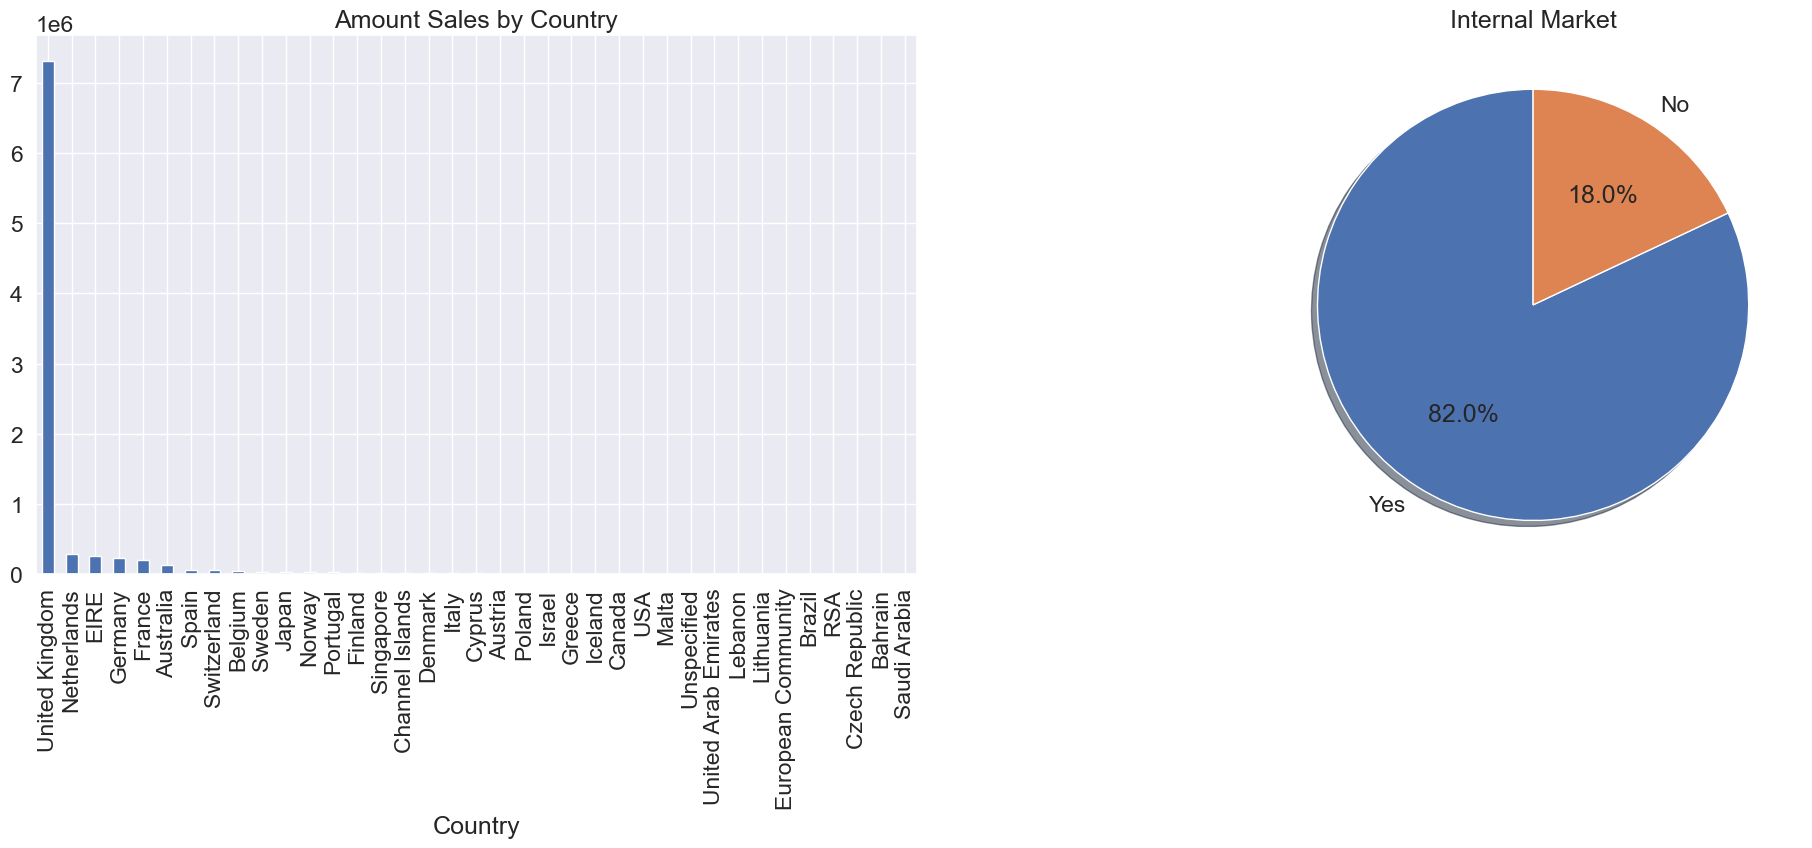

In [62]:
fig = plt.figure(figsize=(25, 7))
f1 = fig.add_subplot(121)
g = cs_df.groupby(["Country"]).amount.sum().sort_values(ascending = False).plot(kind='bar', title='Amount Sales by Country')
cs_df['Internal'] = cs_df.Country.apply(lambda x: 'Yes' if x=='United Kingdom' else 'No' )
f2 = fig.add_subplot(122)
market = cs_df.groupby(["Internal"]).amount.sum().sort_values(ascending = False)
g = plt.pie(market, labels=market.index, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Internal Market')
plt.show()

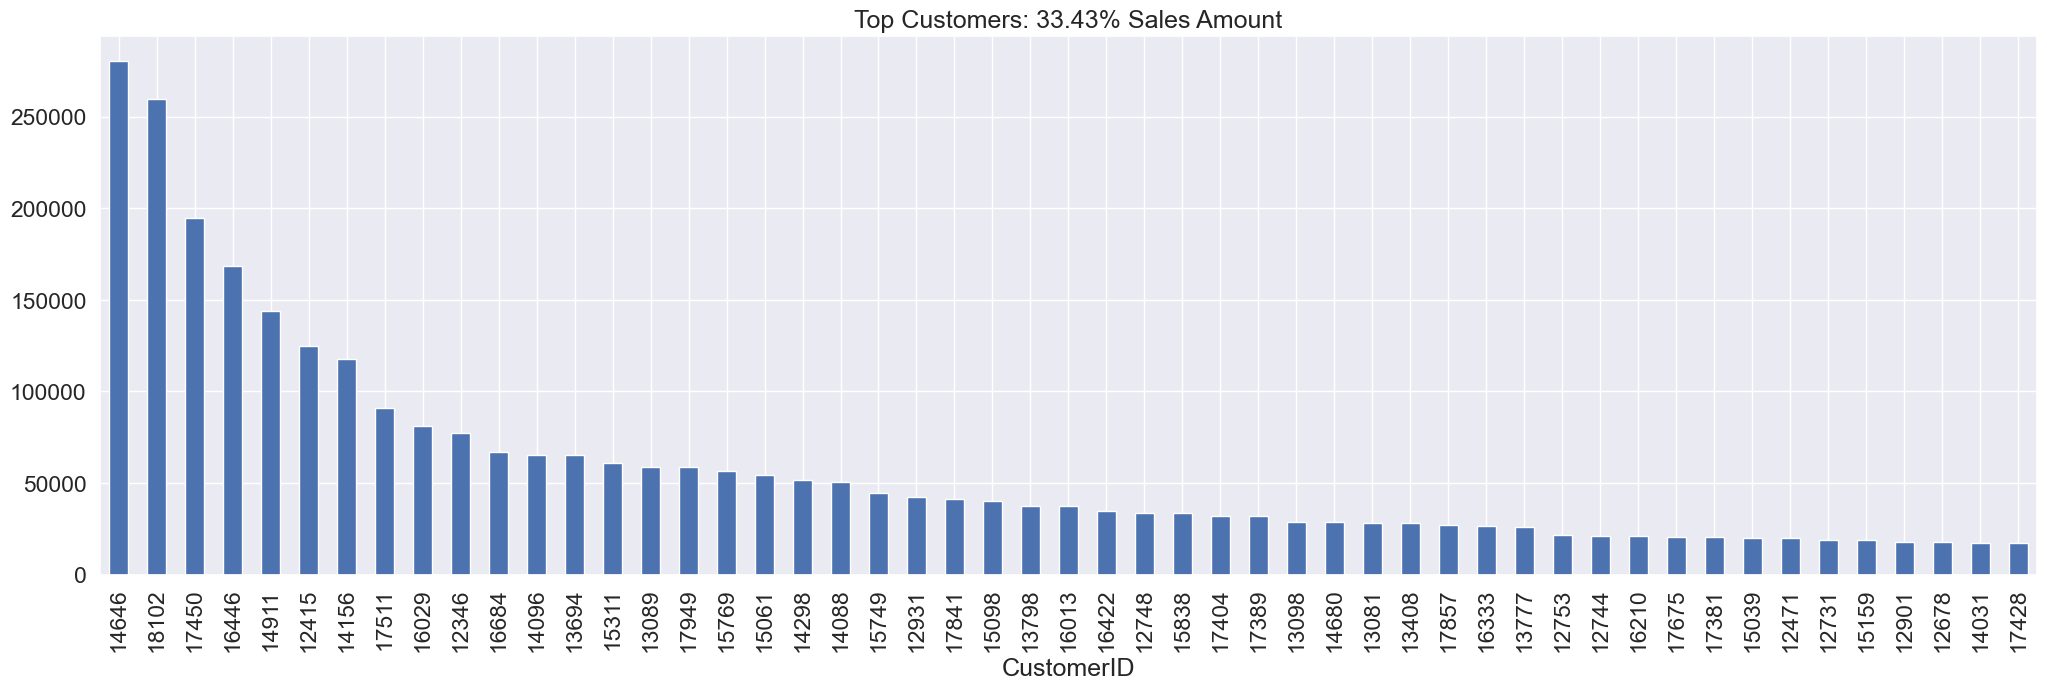

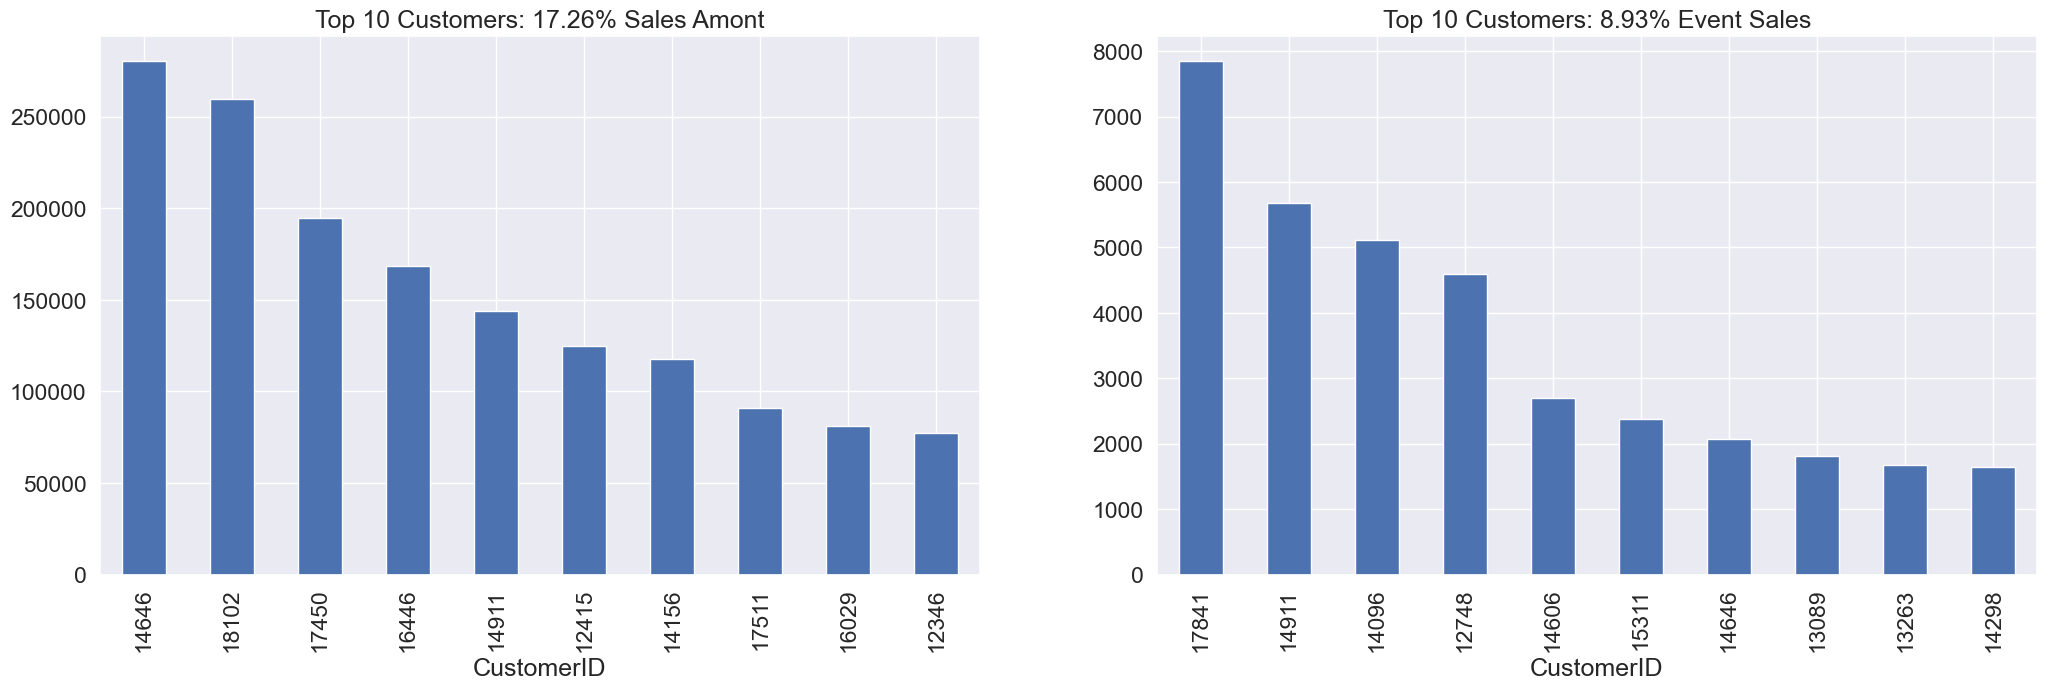

In [63]:
fig = plt.figure(figsize=(25, 7))
PercentSales =  np.round((cs_df.groupby(["CustomerID"]).amount.sum().\
                          sort_values(ascending = False)[:51].sum()/cs_df.groupby(["CustomerID"]).\
                          amount.sum().sort_values(ascending = False).sum()) * 100, 2)
g = cs_df.groupby(["CustomerID"]).amount.sum().sort_values(ascending = False)[:51].\
    plot(kind='bar', title='Top Customers: {:3.2f}% Sales Amount'.format(PercentSales))

fig = plt.figure(figsize=(25, 7))
f1 = fig.add_subplot(121)
PercentSales =  np.round((cs_df.groupby(["CustomerID"]).amount.sum().\
                          sort_values(ascending = False)[:10].sum()/cs_df.groupby(["CustomerID"]).\
                          amount.sum().sort_values(ascending = False).sum()) * 100, 2)
g = cs_df.groupby(["CustomerID"]).amount.sum().sort_values(ascending = False)[:10]\
    .plot(kind='bar', title='Top 10 Customers: {:3.2f}% Sales Amont'.format(PercentSales))
f1 = fig.add_subplot(122)
PercentSales =  np.round((cs_df.groupby(["CustomerID"]).amount.count().\
                          sort_values(ascending = False)[:10].sum()/cs_df.groupby(["CustomerID"]).\
                          amount.count().sort_values(ascending = False).sum()) * 100, 2)
g = cs_df.groupby(["CustomerID"]).amount.count().sort_values(ascending = False)[:10].\
    plot(kind='bar', title='Top 10 Customers: {:3.2f}% Event Sales'.format(PercentSales))

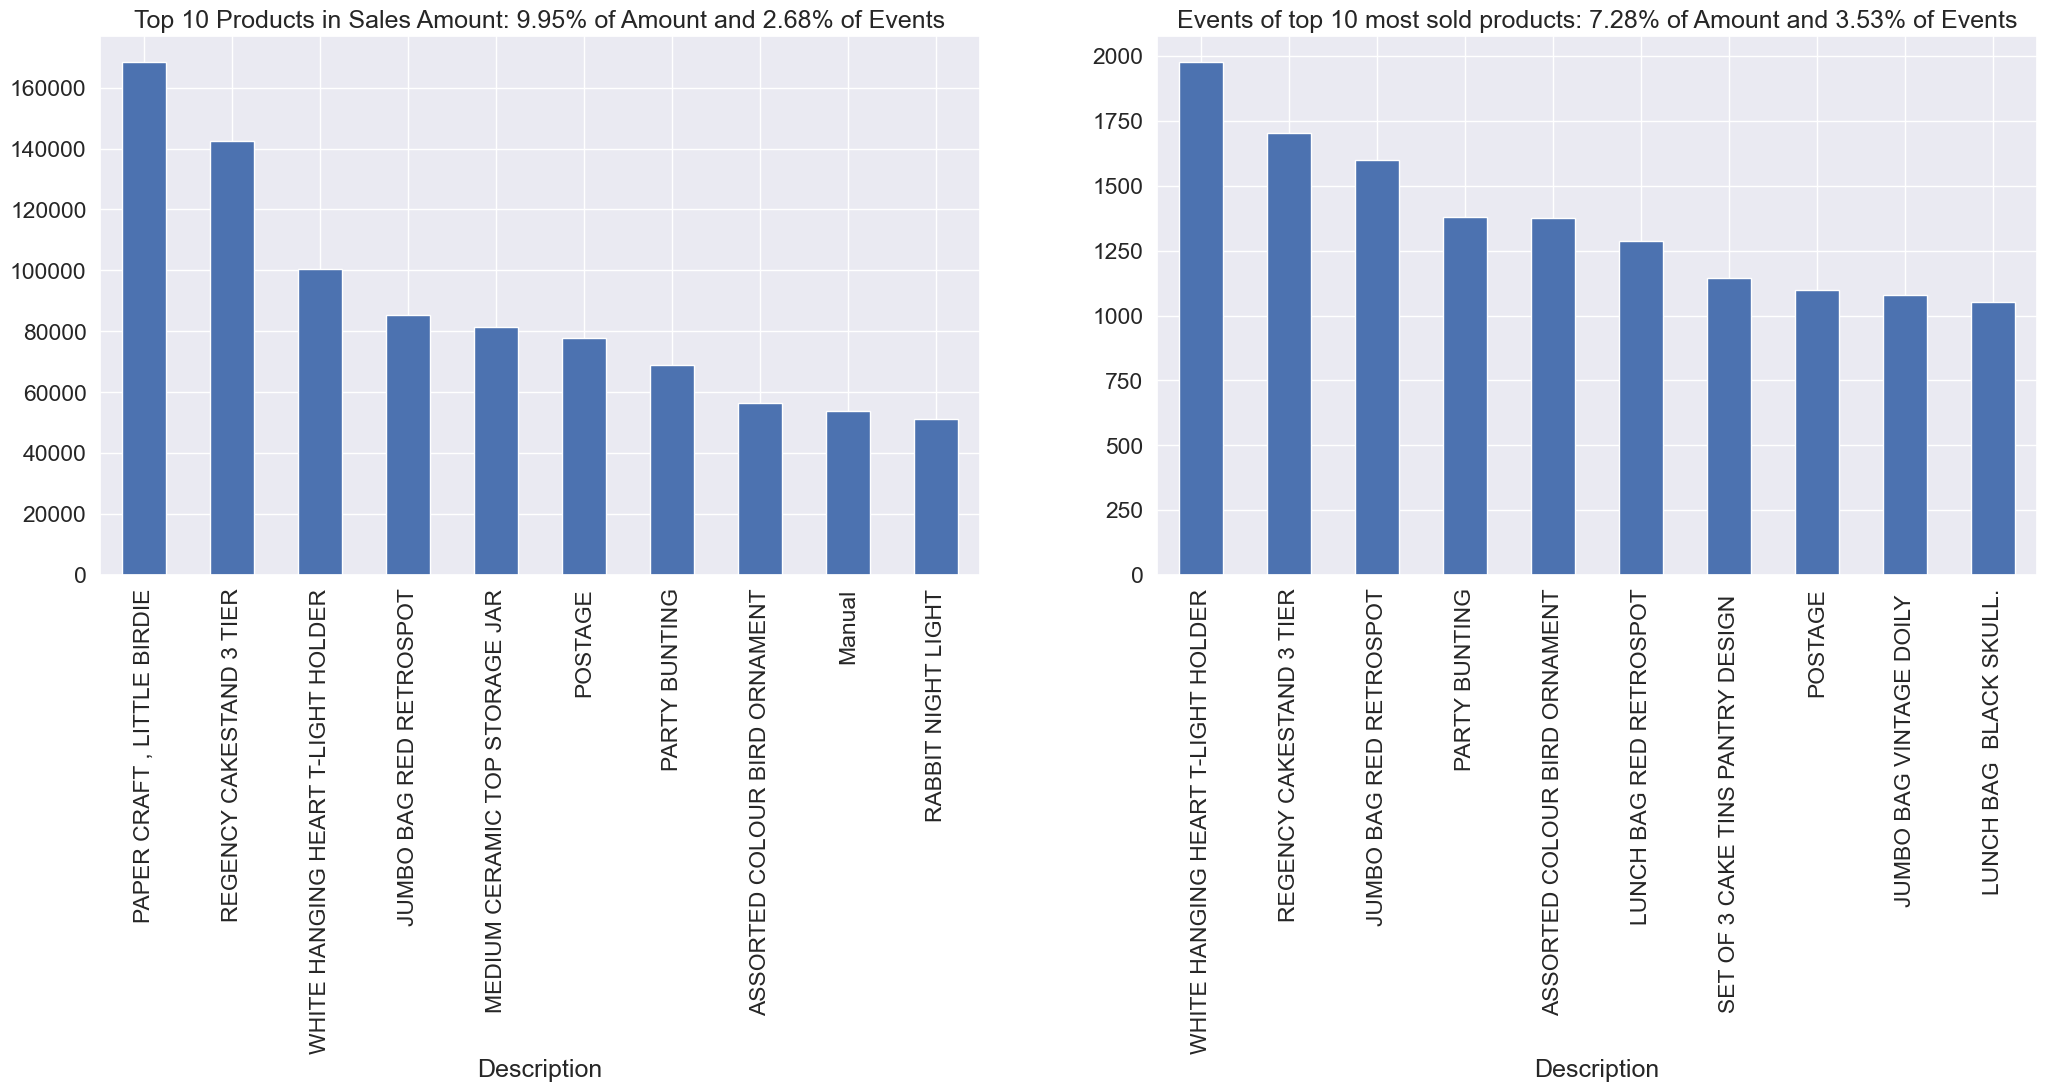

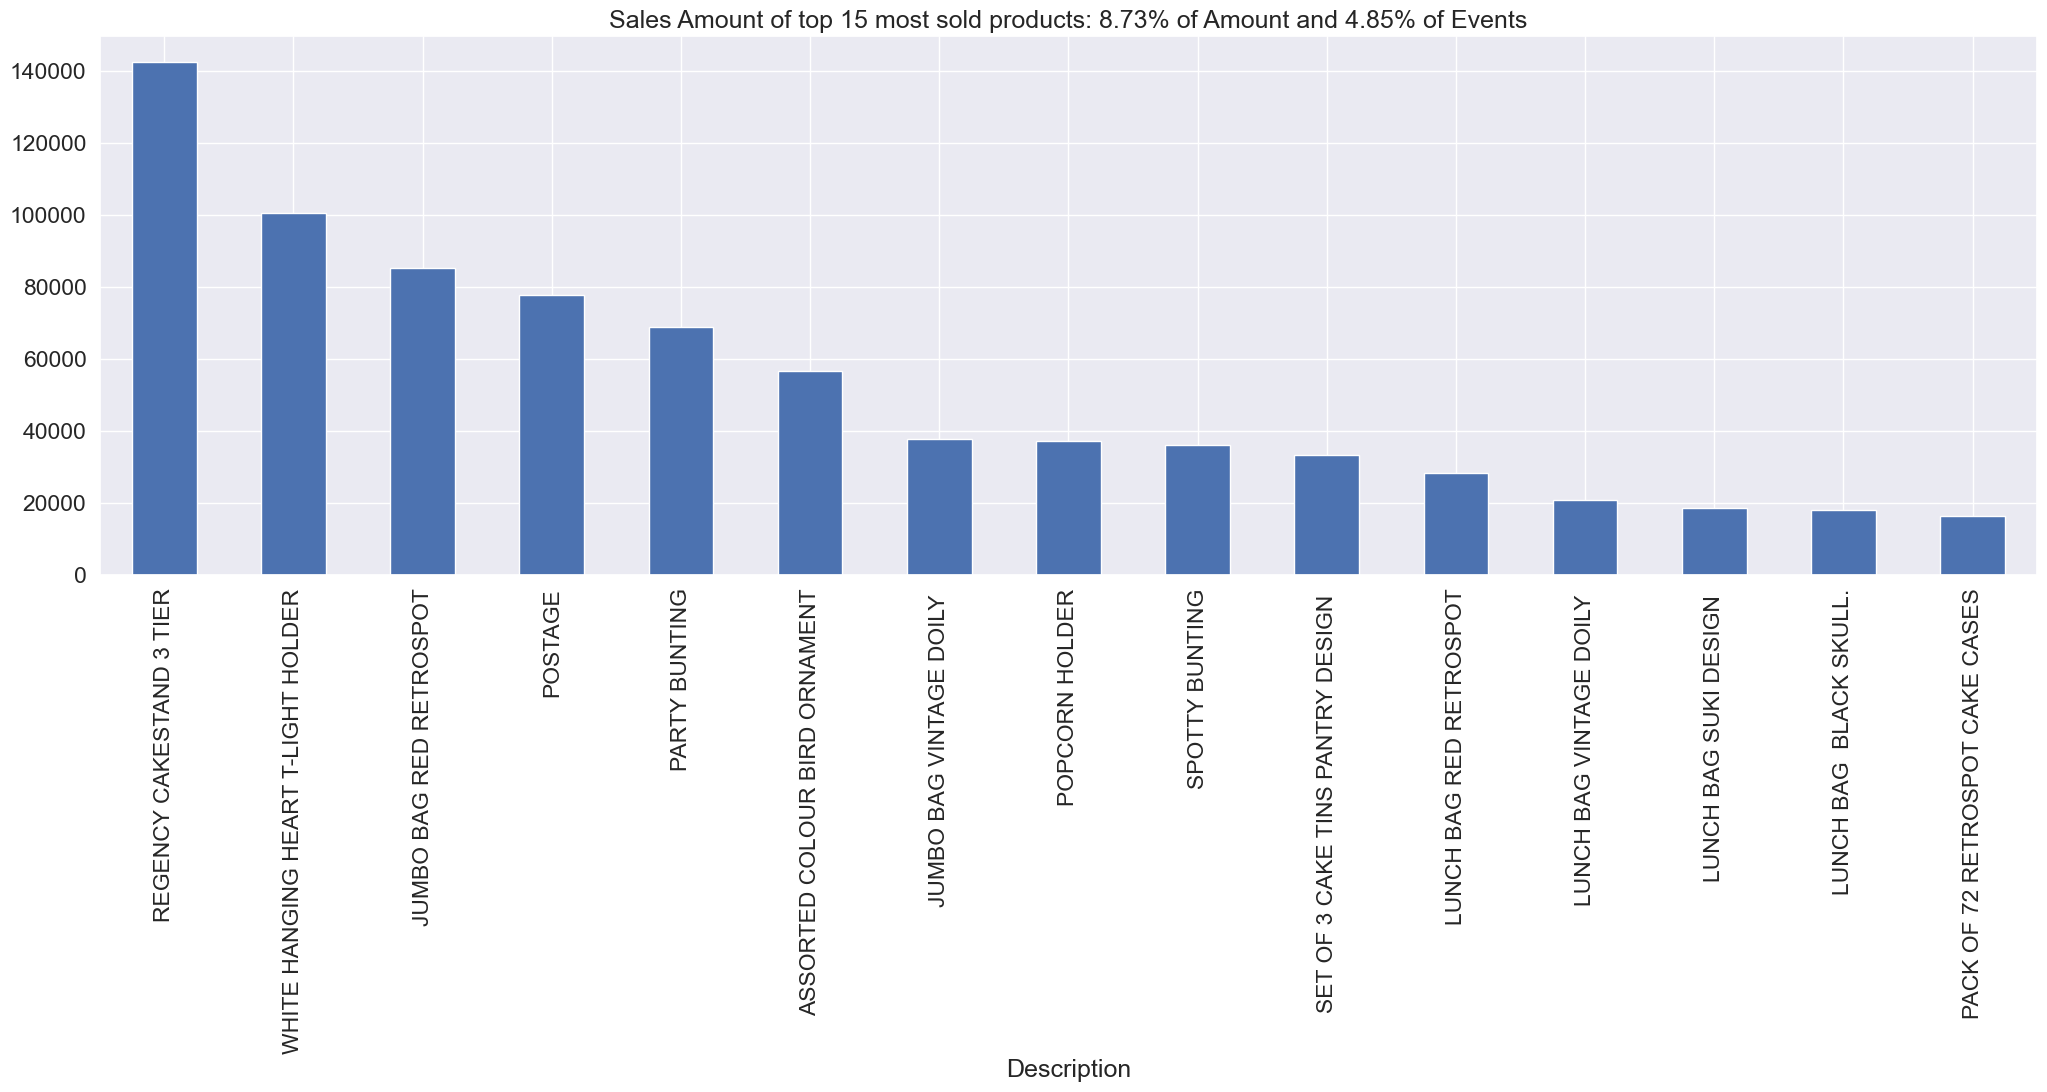

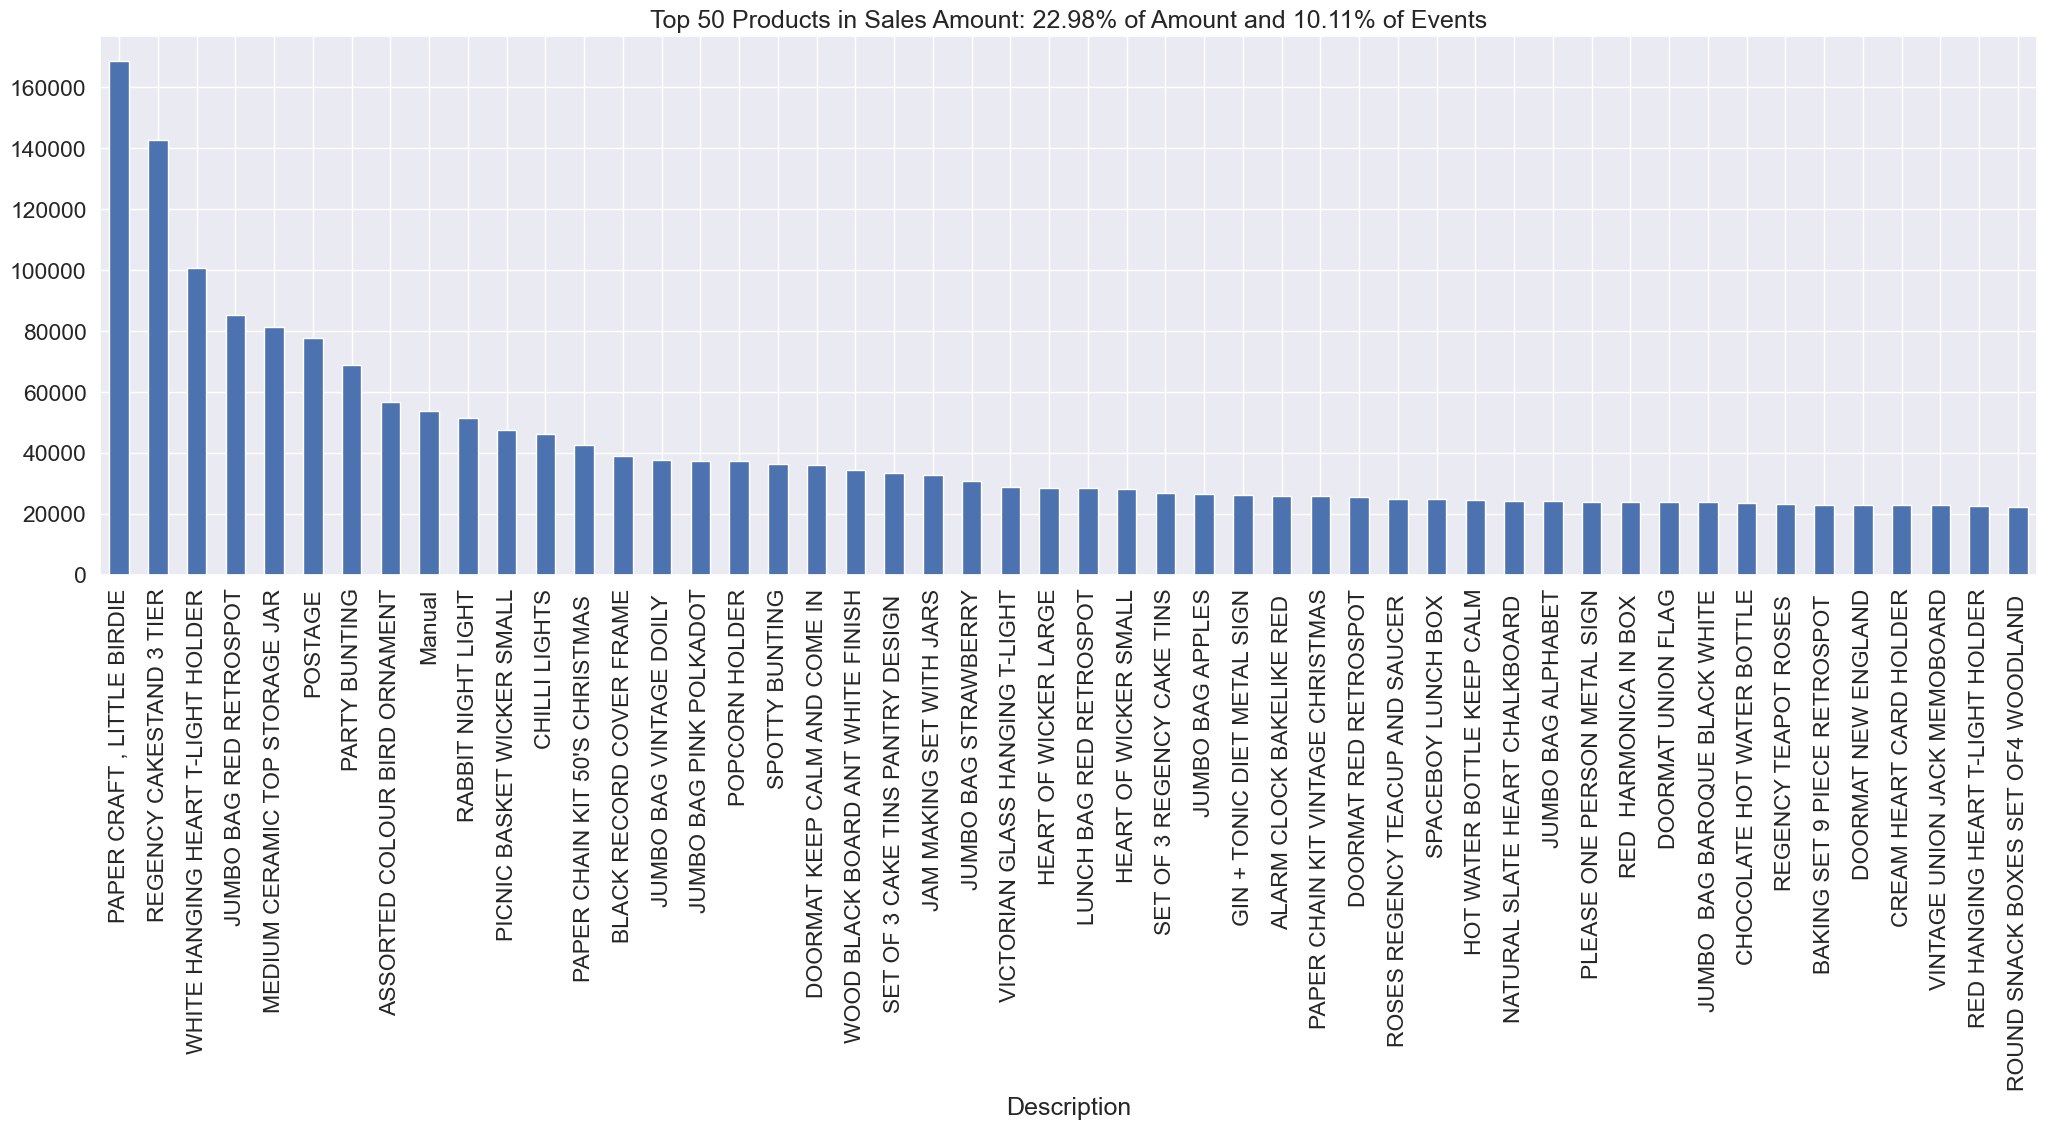

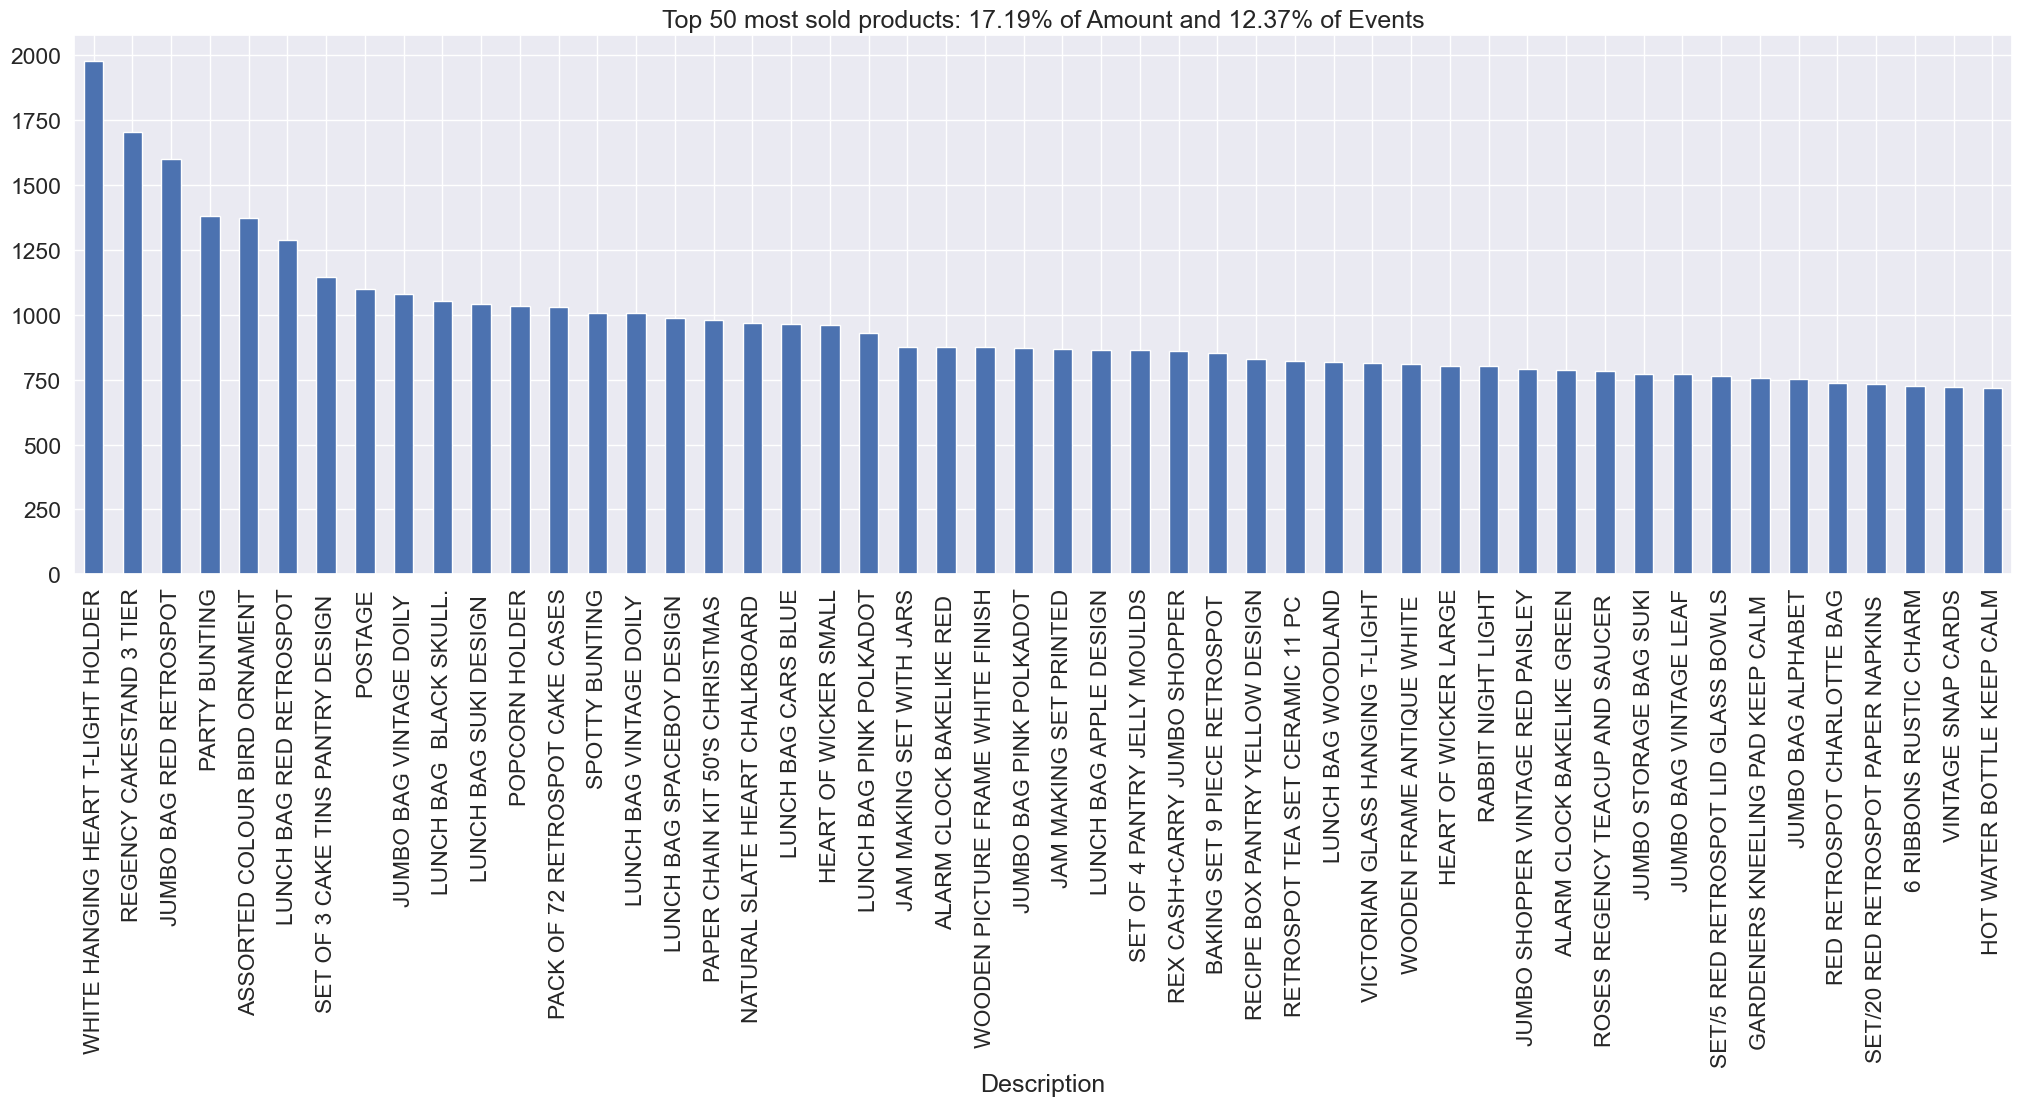

In [64]:
AmoutSum = cs_df.groupby(["Description"]).amount.sum().sort_values(ascending = False)
inv = cs_df[["Description", "InvoiceNo"]].groupby(["Description"]).InvoiceNo.unique().\
      agg(np.size).sort_values(ascending = False)

fig = plt.figure(figsize=(25, 7))
f1 = fig.add_subplot(121)
Top10 = list(AmoutSum[:10].index)
PercentSales =  np.round((AmoutSum[Top10].sum()/AmoutSum.sum()) * 100, 2)
PercentEvents = np.round((inv[Top10].sum()/inv.sum()) * 100, 2)
g = AmoutSum[Top10].\
    plot(kind='bar', title='Top 10 Products in Sales Amount: {:3.2f}% of Amount and {:3.2f}% of Events'.\
                       format(PercentSales, PercentEvents))

f1 = fig.add_subplot(122)
Top10Ev = list(inv[:10].index)
PercentSales =  np.round((AmoutSum[Top10Ev].sum()/AmoutSum.sum()) * 100, 2)
PercentEvents = np.round((inv[Top10Ev].sum()/inv.sum()) * 100, 2)
g = inv[Top10Ev].\
    plot(kind='bar', title='Events of top 10 most sold products: {:3.2f}% of Amount and {:3.2f}% of Events'.\
                       format(PercentSales, PercentEvents))


fig = plt.figure(figsize=(25, 7))
Top15ev = list(inv[:15].index)
PercentSales =  np.round((AmoutSum[Top15ev].sum()/AmoutSum.sum()) * 100, 2)
PercentEvents = np.round((inv[Top15ev].sum()/inv.sum()) * 100, 2)
g = AmoutSum[Top15ev].sort_values(ascending = False).\
    plot(kind='bar', 
         title='Sales Amount of top 15 most sold products: {:3.2f}% of Amount and {:3.2f}% of Events'.\
         format(PercentSales, PercentEvents))

fig = plt.figure(figsize=(25, 7))
Top50 = list(AmoutSum[:50].index)
PercentSales =  np.round((AmoutSum[Top50].sum()/AmoutSum.sum()) * 100, 2)
PercentEvents = np.round((inv[Top50].sum()/inv.sum()) * 100, 2)
g = AmoutSum[Top50].\
    plot(kind='bar', 
         title='Top 50 Products in Sales Amount: {:3.2f}% of Amount and {:3.2f}% of Events'.\
         format(PercentSales, PercentEvents))

fig = plt.figure(figsize=(25, 7))
Top50Ev = list(inv[:50].index)
PercentSales =  np.round((AmoutSum[Top50Ev].sum()/AmoutSum.sum()) * 100, 2)
PercentEvents = np.round((inv[Top50Ev].sum()/inv.sum()) * 100, 2)
g = inv[Top50Ev].\
    plot(kind='bar', title='Top 50 most sold products: {:3.2f}% of Amount and {:3.2f}% of Events'.\
                       format(PercentSales, PercentEvents))


In [65]:
refrence_date = cs_df.InvoiceDate.max() + datetime.timedelta(days = 1)
print('Reference Date:', refrence_date)
cs_df['days_since_last_purchase'] = (refrence_date - cs_df.InvoiceDate).dt.days
customer_history_df =  cs_df[['CustomerID', 'days_since_last_purchase']].groupby("CustomerID").min().reset_index()
customer_history_df.rename(columns={'days_since_last_purchase':'recency'}, inplace=True)
customer_history_df.describe().transpose()

Reference Date: 2011-12-10 12:50:00


,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.0,13813.25,15299.5,16778.75,18287.0
recency,4338.0,92.536422,100.014169,1.0,18.0,51.0,142.0,374.0


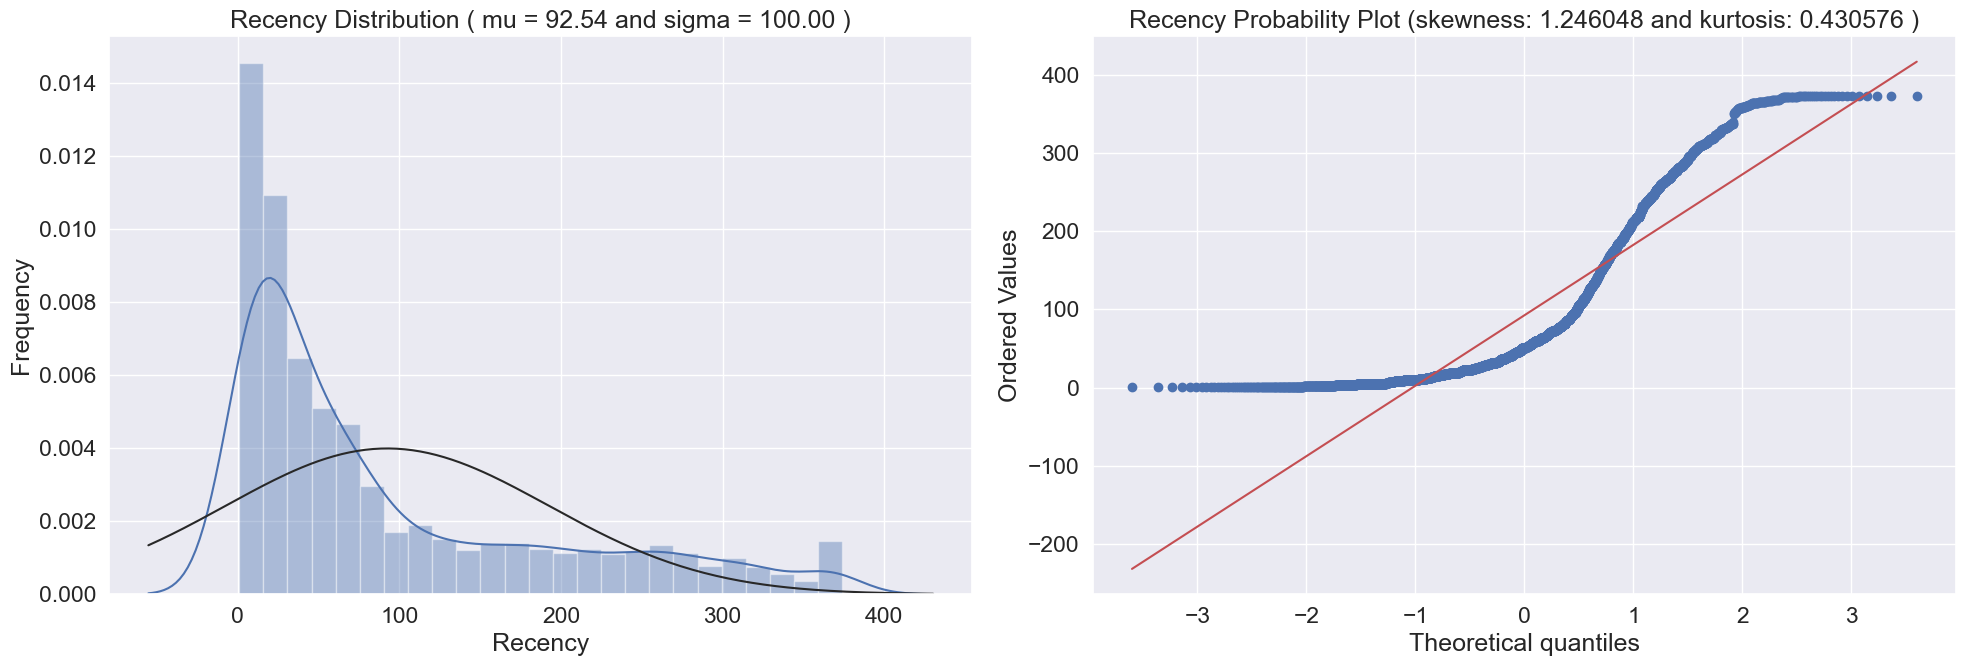

In [66]:
def QQ_plot(data, measure):
    fig = plt.figure(figsize=(20,7))

    #Get the fitted parameters used by the function
    (mu, sigma) = norm.fit(data)

    #Kernel Density plot
    fig1 = fig.add_subplot(121)
    sns.distplot(data, fit=norm)
    fig1.set_title(measure + ' Distribution ( mu = {:.2f} and sigma = {:.2f} )'.format(mu, sigma), loc='center')
    fig1.set_xlabel(measure)
    fig1.set_ylabel('Frequency')

    #QQ plot
    fig2 = fig.add_subplot(122)
    res = probplot(data, plot=fig2)
    fig2.set_title(measure + ' Probability Plot (skewness: {:.6f} and kurtosis: {:.6f} )'.format(data.skew(), data.kurt()), loc='center')

    plt.tight_layout()
    plt.show()

QQ_plot(customer_history_df.recency, 'Recency')

#### Frequency

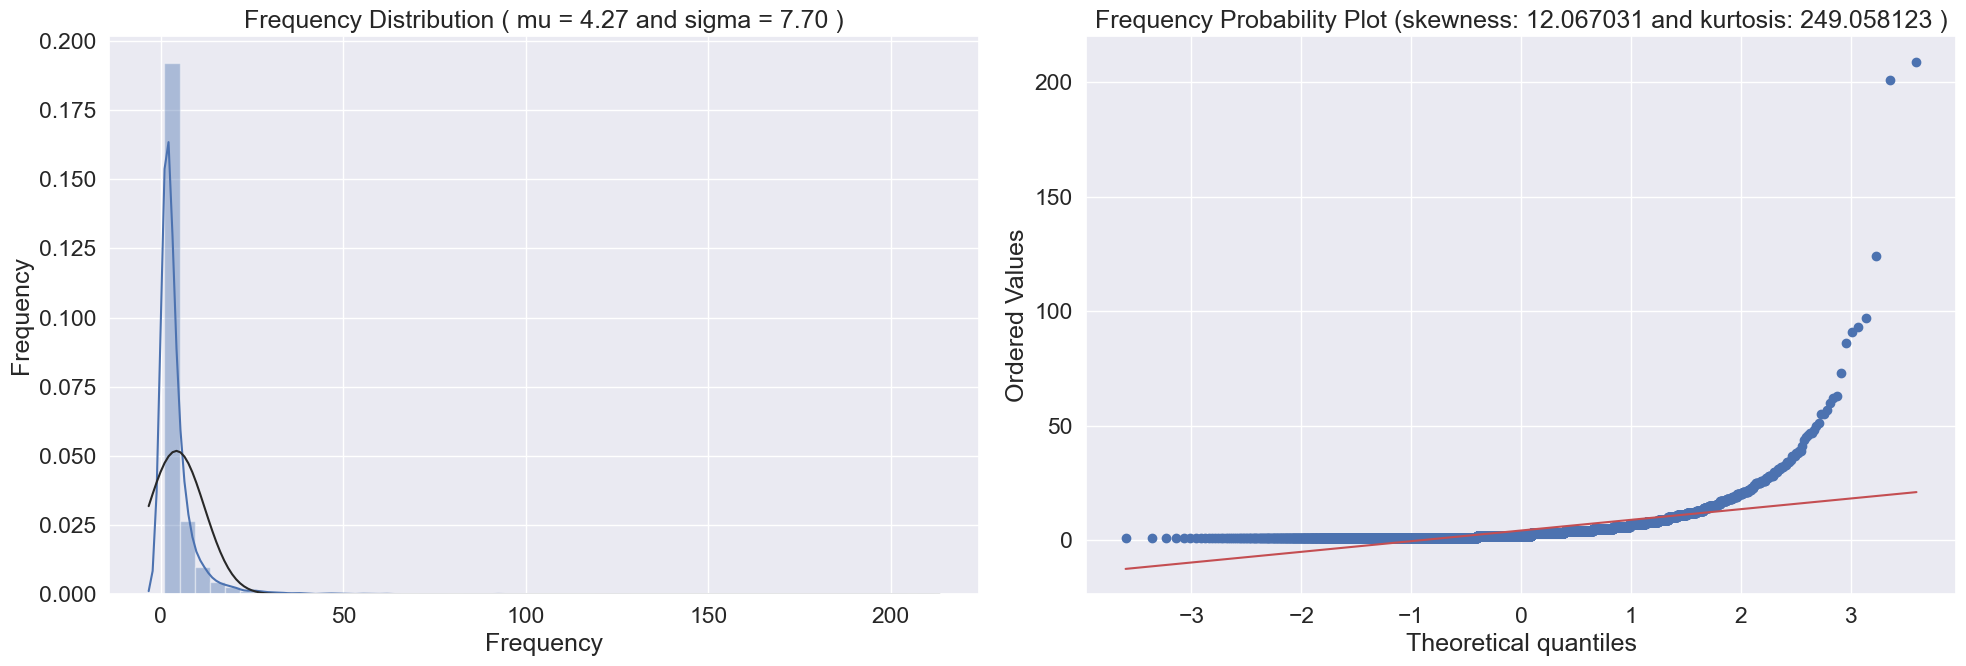

In [67]:
customer_freq = (cs_df[['CustomerID', 'InvoiceNo']].groupby(["CustomerID", 'InvoiceNo']).count().reset_index()).\
                groupby(["CustomerID"]).count().reset_index()
customer_freq.rename(columns={'InvoiceNo':'frequency'},inplace=True)
customer_history_df = customer_history_df.merge(customer_freq)
QQ_plot(customer_history_df.frequency, 'Frequency')

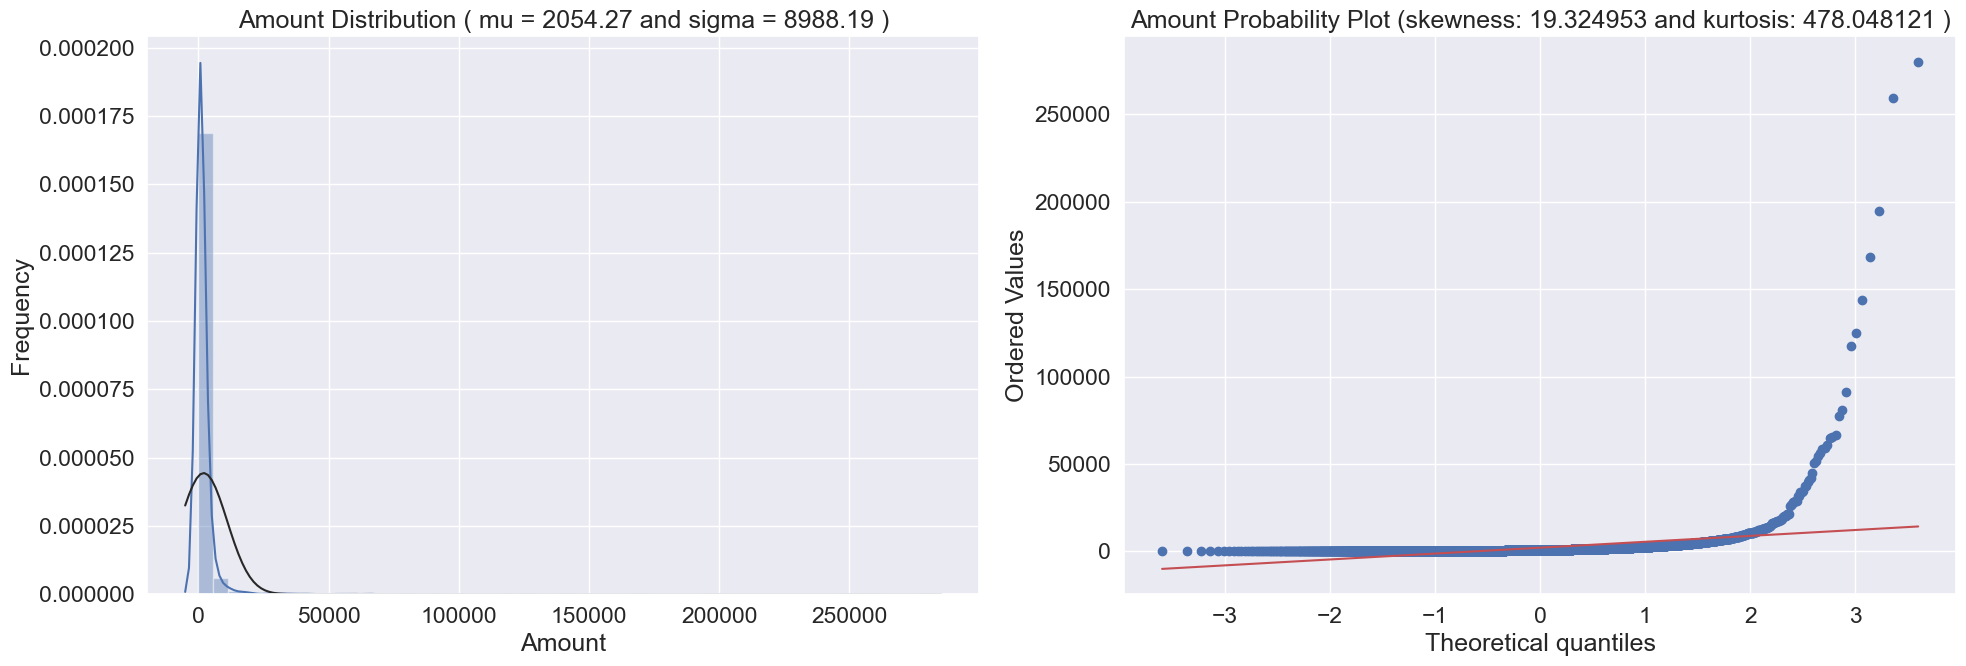

In [68]:
customer_monetary_val = cs_df[['CustomerID', 'amount']].groupby("CustomerID").sum().reset_index()
customer_history_df = customer_history_df.merge(customer_monetary_val)
QQ_plot(customer_history_df.amount, 'Amount')

In [1]:
customer_history_df.describe()

NameError: name 'customer_history_df' is not defined

### 4. Data Preprocessing

In [70]:
customer_history_df['recency_log'] = customer_history_df['recency'].apply(math.log)
customer_history_df['frequency_log'] = customer_history_df['frequency'].apply(math.log)
customer_history_df['amount_log'] = customer_history_df['amount'].apply(math.log)
feature_vector = ['amount_log', 'recency_log','frequency_log']
X_subset = customer_history_df[feature_vector] #.as_matrix()
scaler = preprocessing.StandardScaler().fit(X_subset)
X_scaled = scaler.transform(X_subset)
pd.DataFrame(X_scaled, columns=X_subset.columns).describe().T

,count,mean,std,min,25%,50%,75%,max
amount_log,4338.0,-7.010426e-16,1.000115,-4.179280,-0.684183,-0.060942,0.654244,4.721395
recency_log,4338.0,-1.048288e-16,1.000115,-2.630445,-0.612424,0.114707,0.829652,1.505796
frequency_log,4338.0,-9.991495e-17,1.000115,-1.048610,-1.048610,-0.279044,0.738267,4.882714


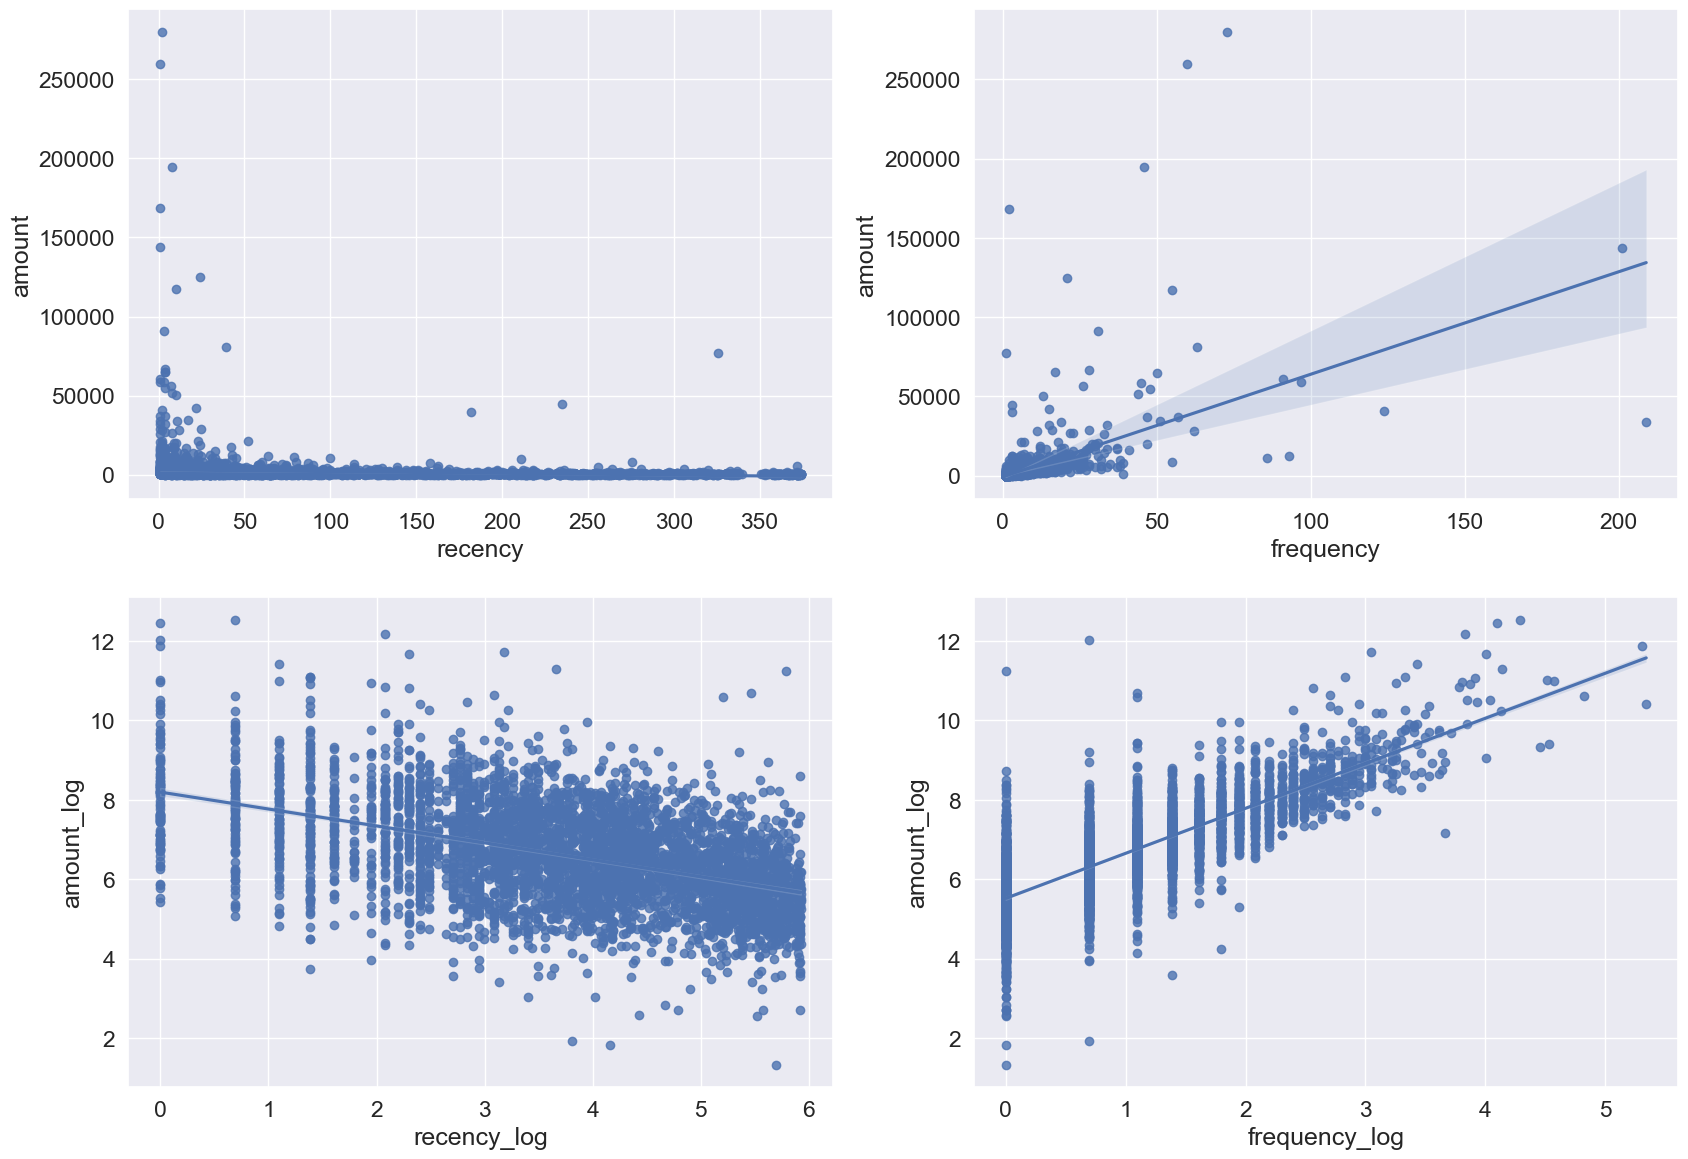

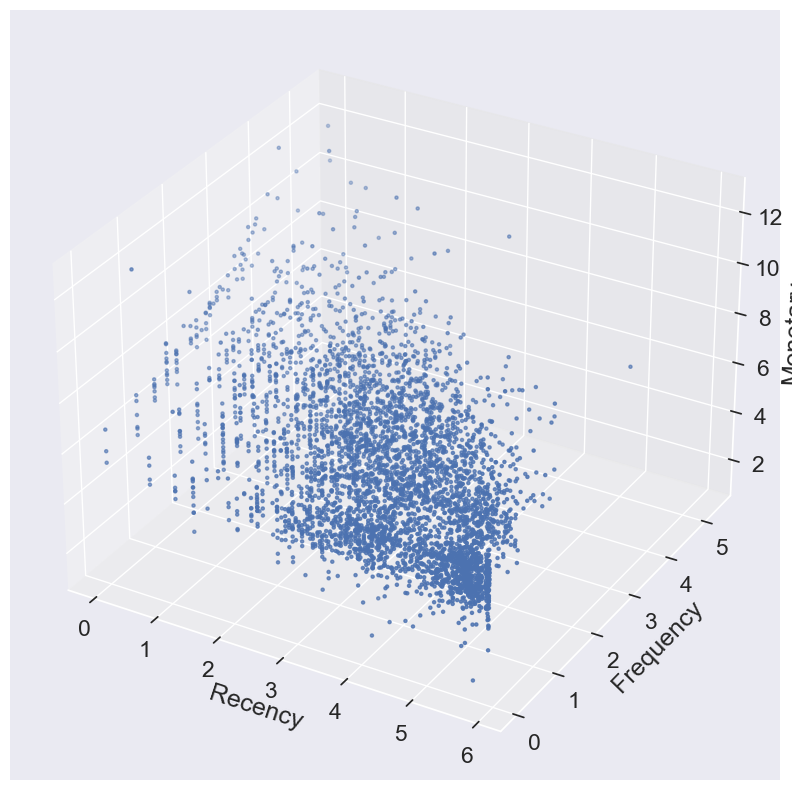

Data exported to customer_history.csv


In [71]:
fig = plt.figure(figsize=(20,14))
f1 = fig.add_subplot(221); sns.regplot(x='recency', y='amount', data=customer_history_df)
f1 = fig.add_subplot(222); sns.regplot(x='frequency', y='amount', data=customer_history_df)
f1 = fig.add_subplot(223); sns.regplot(x='recency_log', y='amount_log', data=customer_history_df)
f1 = fig.add_subplot(224); sns.regplot(x='frequency_log', y='amount_log', data=customer_history_df)

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

xs =customer_history_df.recency_log
ys = customer_history_df.frequency_log
zs = customer_history_df.amount_log
ax.scatter(xs, ys, zs, s=5)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

plt.show()

# print(customer_history_df[:10])

# Export customer history data to CSV
csv_file_path = 'customer_history.csv'
customer_history_df.to_csv(csv_file_path, index=False)
print(f"Data exported to {csv_file_path}")


### 5. Clustering for Segments
#### K-Means Clustering

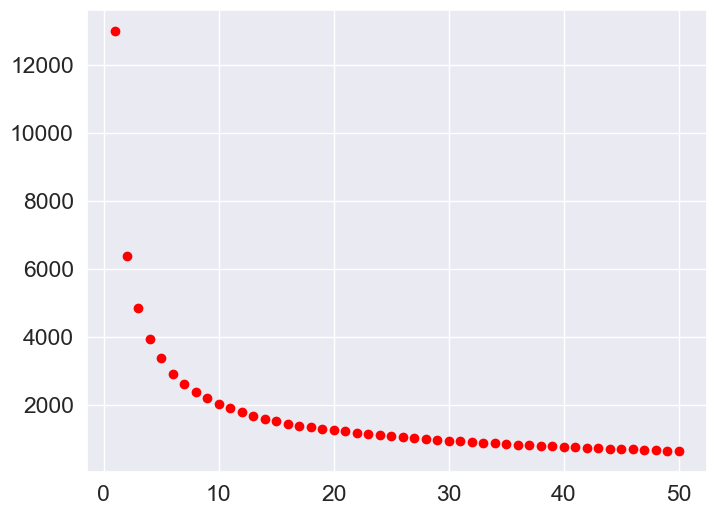

The best K sugest:  7


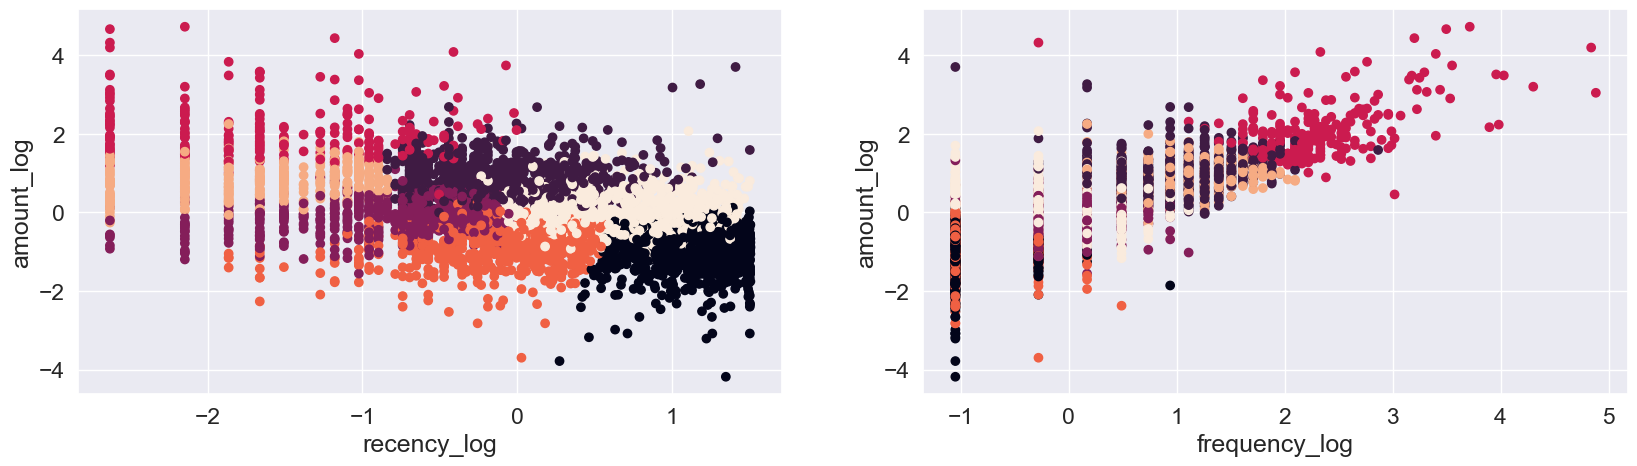

In [72]:
cl = 50
corte = 0.1

anterior = 100000000000000
cost = [] 
K_best = cl

for k in range (1, cl+1):
    # Create a kmeans model on our data, using k clusters.  random_state helps ensure that the algorithm returns the same results each time.
    model = KMeans(
        n_clusters=k, 
        init='k-means++', #'random',
        n_init=10,
        max_iter=300,
        tol=1e-04,
        random_state=101)

    model = model.fit(X_scaled)

    # These are our fitted labels for clusters -- the first cluster has label 0, and the second has label 1.
    labels = model.labels_
 
    # Sum of distances of samples to their closest cluster center
    interia = model.inertia_
    if (K_best == cl) and (((anterior - interia)/anterior) < corte): K_best = k - 1
    cost.append(interia)
    anterior = interia

plt.figure(figsize=(8, 6))
plt.scatter(range (1, cl+1), cost, c='red')
plt.show()

# Create a kmeans model with the best K.
print('The best K sugest: ',K_best)
model = KMeans(n_clusters=K_best, init='k-means++', n_init=10,max_iter=300, tol=1e-04, random_state=101)

# Note I'm scaling the data to normalize it! Important for good results.
model = model.fit(X_scaled)

# These are our fitted labels for clusters -- the first cluster has label 0, and the second has label 1.
labels = model.labels_

# And we'll visualize it:
#plt.scatter(X_scaled[:,0], X_scaled[:,1], c=model.labels_.astype(float))
fig = plt.figure(figsize=(20,5))
ax = fig.add_subplot(121)
plt.scatter(x = X_scaled[:,1], y = X_scaled[:,0], c=model.labels_.astype(float))
ax.set_xlabel(feature_vector[1])
ax.set_ylabel(feature_vector[0])
ax = fig.add_subplot(122)
plt.scatter(x = X_scaled[:,2], y = X_scaled[:,0], c=model.labels_.astype(float))
ax.set_xlabel(feature_vector[2])
ax.set_ylabel(feature_vector[0])

plt.show()

#### Silhouette analysis on K-Means clustering

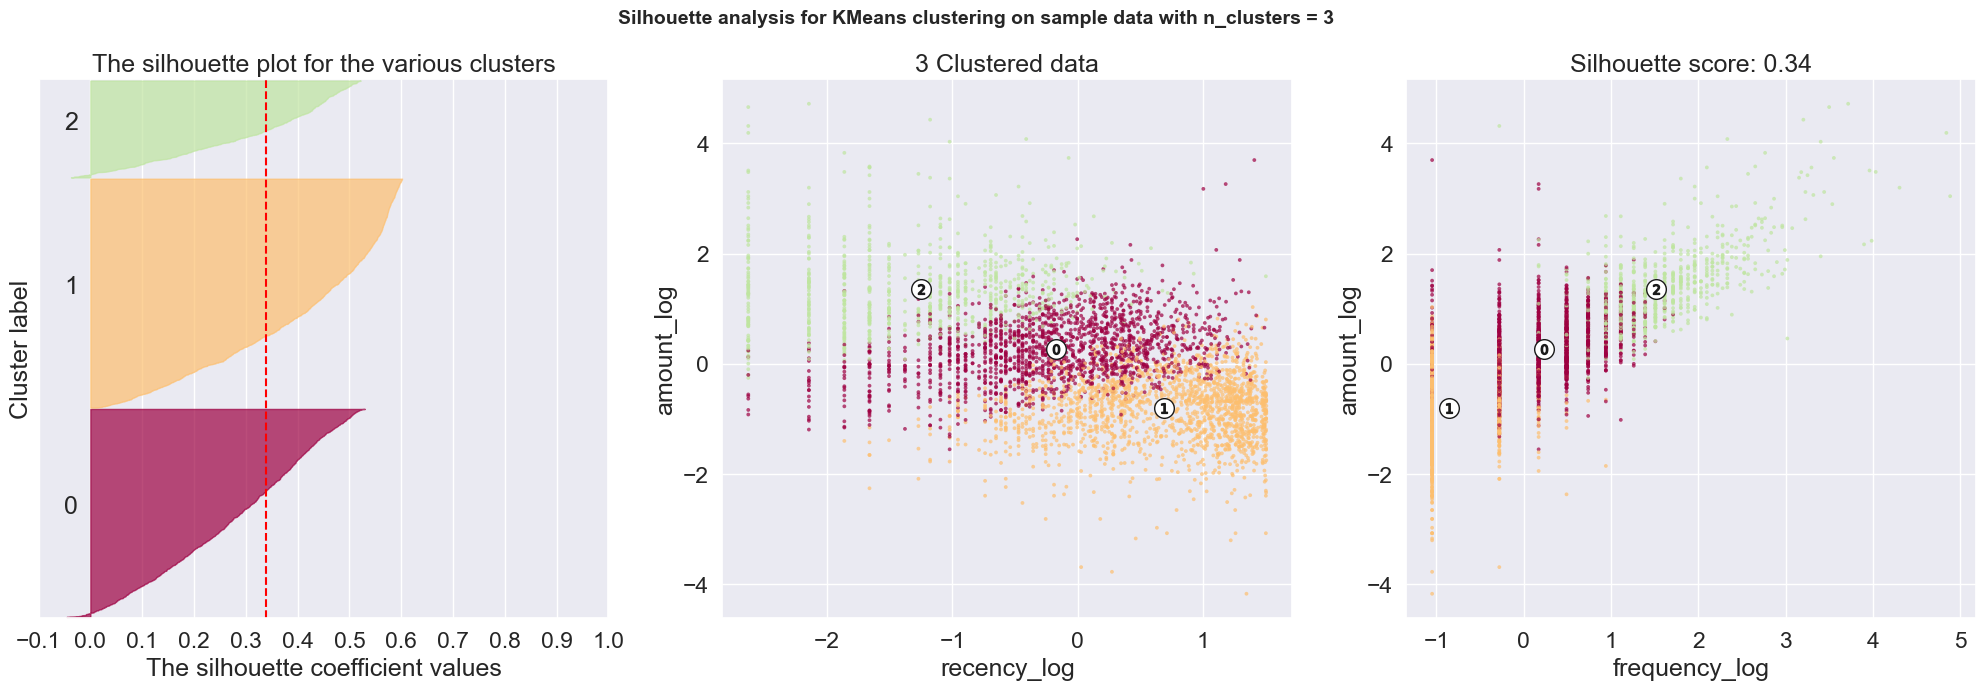

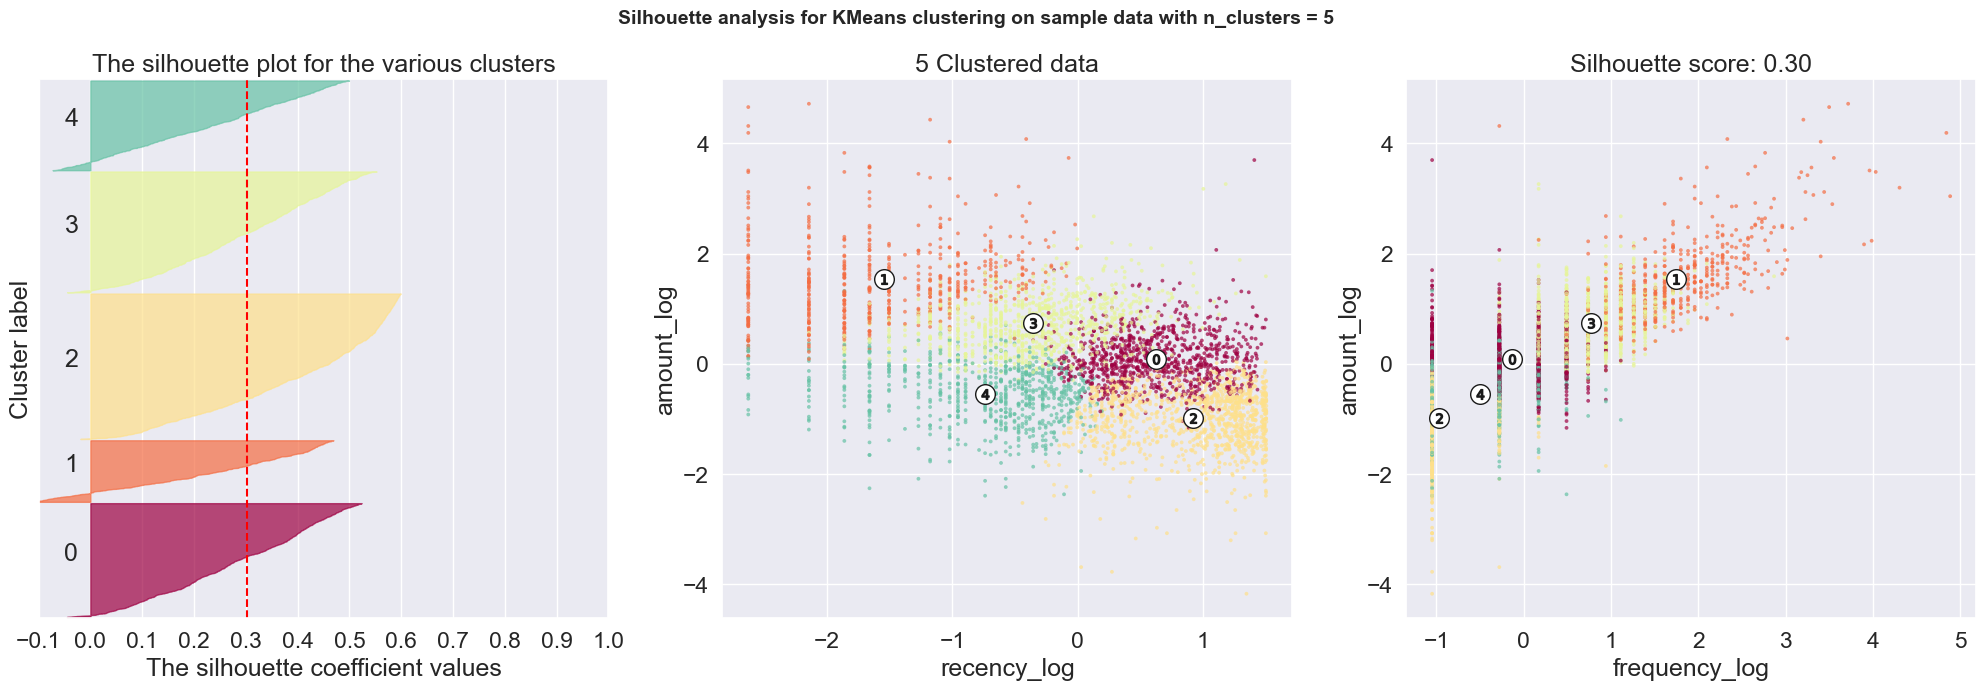

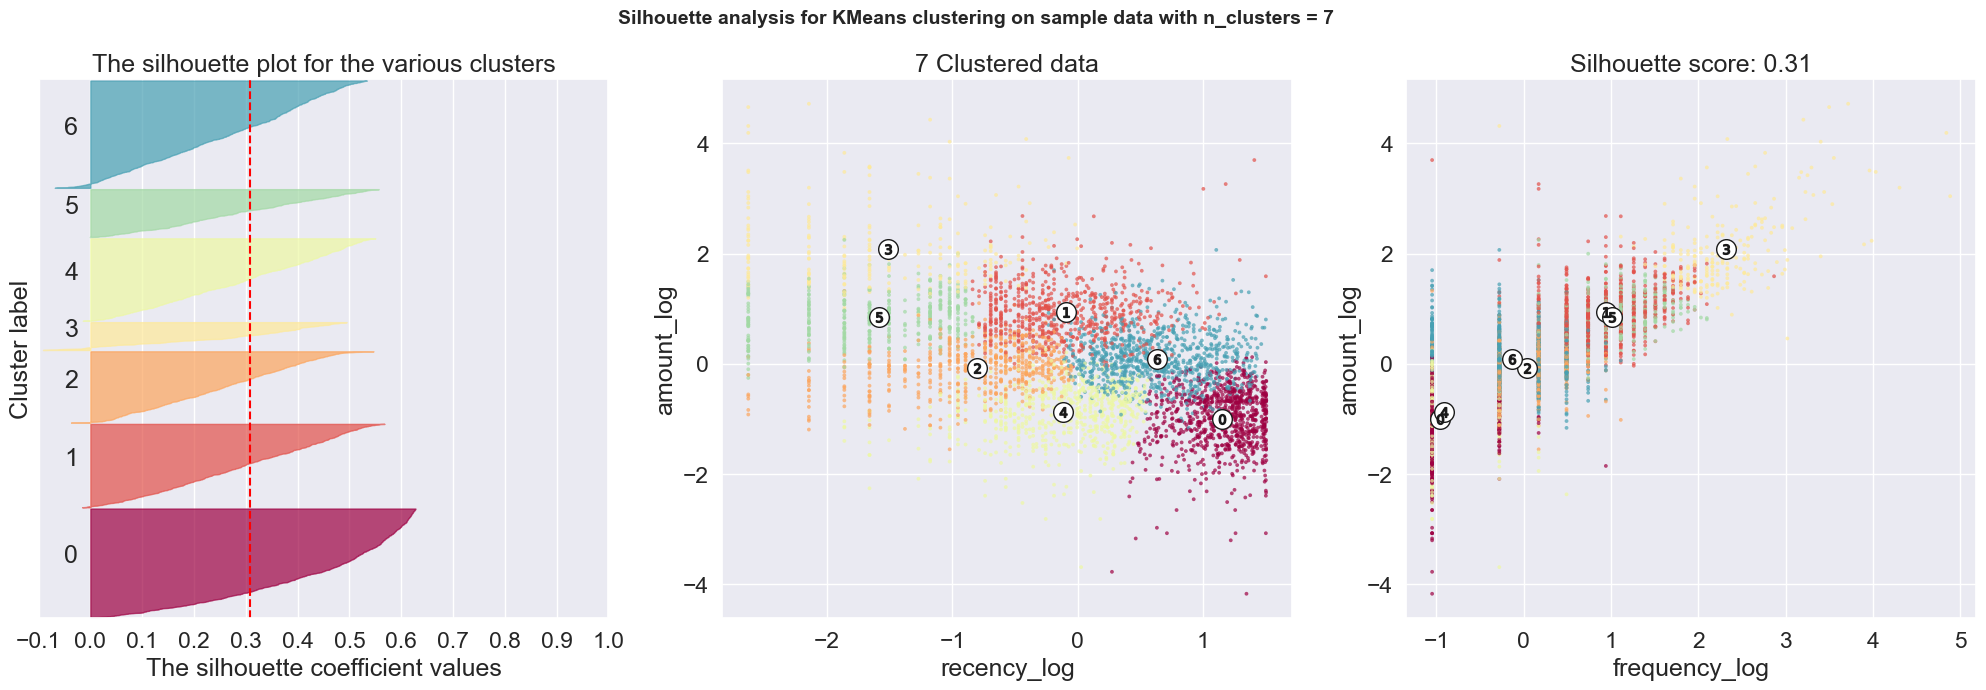

In [73]:
cluster_centers = dict()

for n_clusters in range(3,K_best+1,2):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
    fig.set_size_inches(25, 7)
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10,max_iter=300, tol=1e-04, random_state=101)
    cluster_labels = clusterer.fit_predict(X_scaled)

    silhouette_avg = silhouette_score(X = X_scaled, labels = cluster_labels)
    cluster_centers.update({n_clusters :{'cluster_center':clusterer.cluster_centers_,
                                         'silhouette_score':silhouette_avg,
                                         'labels':cluster_labels}
                           })

    sample_silhouette_values = silhouette_samples(X = X_scaled, labels = cluster_labels)
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.Spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
    colors = cm.Spectral(cluster_labels.astype(float) / n_clusters)
    
    centers = clusterer.cluster_centers_
    y = 0
    x = 1
    ax2.scatter(X_scaled[:, x], X_scaled[:, y], marker='.', s=30, lw=0, alpha=0.7, c=colors, edgecolor='k')   
    ax2.scatter(centers[:, x], centers[:, y], marker='o', c="white", alpha=1, s=200, edgecolor='k')
    for i, c in enumerate(centers):
        ax2.scatter(c[x], c[y], marker='$%d$' % i, alpha=1, s=50, edgecolor='k')
    ax2.set_title("{} Clustered data".format(n_clusters))
    ax2.set_xlabel(feature_vector[x])
    ax2.set_ylabel(feature_vector[y])

    x = 2
    ax3.scatter(X_scaled[:, x], X_scaled[:, y], marker='.', s=30, lw=0, alpha=0.7, c=colors, edgecolor='k')   
    ax3.scatter(centers[:, x], centers[:, y], marker='o', c="white", alpha=1, s=200, edgecolor='k')
    for i, c in enumerate(centers):
        ax3.scatter(c[x], c[y], marker='$%d$' % i, alpha=1, s=50, edgecolor='k')
    ax3.set_title("Silhouette score: {:1.2f}".format(cluster_centers[n_clusters]['silhouette_score']))
    ax3.set_xlabel(feature_vector[x])
    ax3.set_ylabel(feature_vector[y])
    
    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')
    plt.show()

#### 6. Clusters Center

In [74]:
features = ['amount',  'recency',  'frequency']
for i in range(3,K_best+1,2):
    print("for {} clusters the silhouette score is {:1.2f}".format(i, cluster_centers[i]['silhouette_score']))
    print("Centers of each cluster:")
    cent_transformed = scaler.inverse_transform(cluster_centers[i]['cluster_center'])
    print(pd.DataFrame(np.exp(cent_transformed),columns=features))
    print('-'*50)

for 3 clusters the silhouette score is 0.34
Centers of each cluster:
        amount     recency  frequency
0  1019.114007   33.637514   3.171771
1   262.853859  115.772727   1.196009
2  3983.322212    7.173427  10.099071
--------------------------------------------------
for 5 clusters the silhouette score is 0.30
Centers of each cluster:
        amount     recency  frequency
0   813.621211  105.524342   2.279822
1  5051.937209    4.728829  12.403678
2   208.013492  162.151056   1.075721
3  1830.850445   25.873099   5.126046
4   366.981282   15.050233   1.644625
--------------------------------------------------
for 7 clusters the silhouette score is 0.31
Centers of each cluster:
         amount     recency  frequency
0    205.487848  225.646442   1.084052
1   2401.476039   37.751906   6.002805
2    657.936736   13.675696   2.647270
3  10143.118638    4.926439  20.646017
4    239.411000   36.717710   1.130641
5   2114.266897    4.458579   6.365225
6    814.574493  107.556965   2.277767

#### 7. Drill Down Clusters

,CustomerID,recency,frequency,amount,recency_log,frequency_log,amount_log,clusters_3,clusters_5,clusters_7
0,12346,326,1,77183.60,5.786897,0.000000,11.253942,0,0,1
1,12347,2,7,4310.00,0.693147,1.945910,8.368693,2,1,5
2,12348,75,4,1797.24,4.317488,1.386294,7.494007,0,3,1
3,12349,19,1,1757.55,2.944439,0.000000,7.471676,0,4,2
4,12350,310,1,334.40,5.736572,0.000000,5.812338,1,2,0


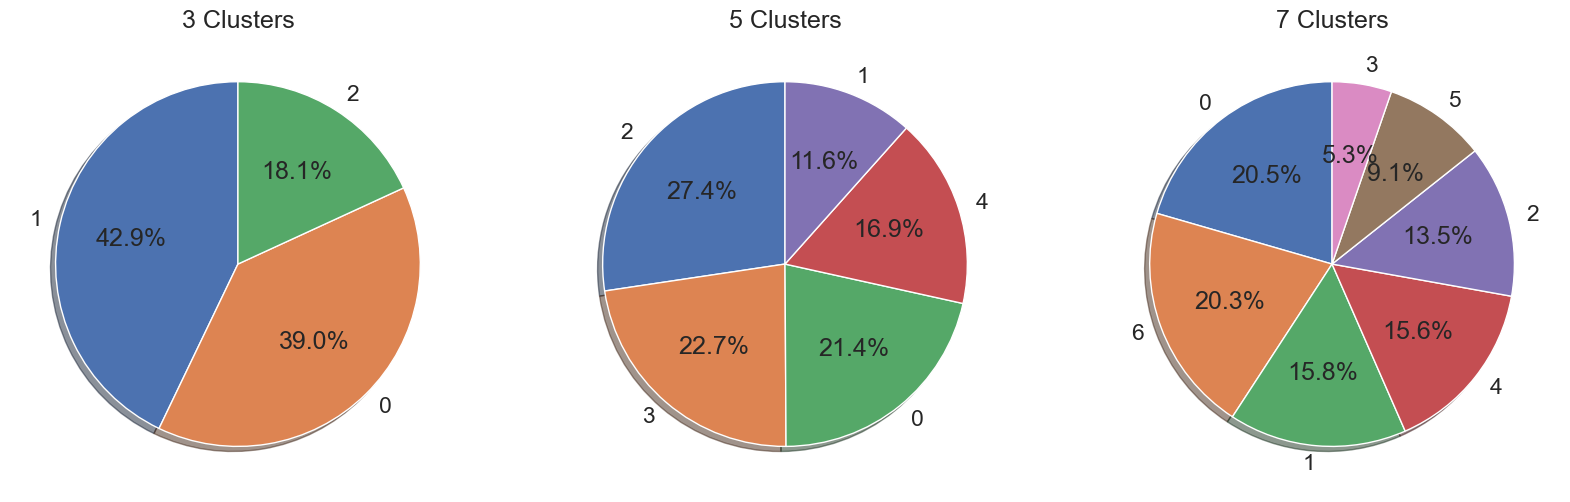

In [75]:
customer_history_df['clusters_3'] = cluster_centers[3]['labels'] 
customer_history_df['clusters_5'] = cluster_centers[5]['labels']
customer_history_df['clusters_7'] = cluster_centers[7]['labels']
display(customer_history_df.head())

fig = plt.figure(figsize=(20,7))
f1 = fig.add_subplot(131)
market = customer_history_df.clusters_3.value_counts()
g = plt.pie(market, labels=market.index, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('3 Clusters')
f1 = fig.add_subplot(132)
market = customer_history_df.clusters_5.value_counts()
g = plt.pie(market, labels=market.index, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('5 Clusters')
f1 = fig.add_subplot(133)
market = customer_history_df.clusters_7.value_counts()
g = plt.pie(market, labels=market.index, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('7 Clusters')
plt.show()

Once we have the labels assigned to each of the customers, our task is simple. Now we want to find out how the summary of customer in each group is varying. If we can visualize that information we will able to find out the differences in the clusters of customers and we can modify our strategy on the basis of those differences.

The following code leverages plotly and will take the cluster labels we got for each configurations clusters and create boxplots. Plotly enables us to interact with the plots to see the central tendency values in each boxplot in the notebook. Note that we want to avoid the extremely high outlier values of each group, as they will interfere in making a good observation around the central tendencies of each cluster. Since we have only positive values, we will restrict the data such that only data points which are less than 0.95th percentile of the cluster is used. This will give us good information about the majority of the users in that cluster segment.

I've used these charts to review my previously stated insights, but follow the same for you to explore:

In [76]:
x_data = ['Cluster 0', 'Cluster 1','Cluster 2','Cluster 3','Cluster 4', 'Cluster 5', 'Cluster 6']
colors = ['rgba(93, 164, 214, 0.5)', 'rgba(255, 144, 14, 0.5)', 'rgba(44, 160, 101, 0.5)', 'rgba(255, 65, 54, 0.5)', 
          'rgba(22, 80, 57, 0.5)', 'rgba(127, 65, 14, 0.5)', 'rgba(207, 114, 255, 0.5)', 'rgba(127, 96, 0, 0.5)']
cutoff_quantile = 95

for n_clusters in range(3,K_best+1,2):
    cl = 'clusters_' + str(n_clusters)
    for fild in range(0, 3):
        field_to_plot = features[fild]        
        y_data = list()
        ymax = 0
        for i in np.arange(0,n_clusters):
            y0 = customer_history_df[customer_history_df[cl]==i][field_to_plot].values
            y0 = y0[y0<np.percentile(y0, cutoff_quantile)]
            if ymax < max(y0): ymax = max(y0)
            y_data.insert(i, y0)

        traces = []

        for xd, yd, cls in zip(x_data[:n_clusters], y_data, colors[:n_clusters]):
                traces.append(go.Box(y=yd, name=xd, boxpoints=False, jitter=0.5, whiskerwidth=0.2, fillcolor=cls,
                    marker=dict( size=1, ),
                    line=dict(width=1),
                ))

        layout = go.Layout(
            title='Difference in {} with {} Clusters and {:1.2f} Score'.\
            format(field_to_plot, n_clusters, cluster_centers[n_clusters]['silhouette_score']),
            yaxis=dict( autorange=True, showgrid=True, zeroline=True,
                dtick = int(ymax/10),
                gridcolor='black', gridwidth=0.1, zerolinecolor='rgb(255, 255, 255)', zerolinewidth=2, ),
            margin=dict(l=40, r=30, b=50, t=50, ),
            paper_bgcolor='white',
            plot_bgcolor='white',
            showlegend=False
        )

        fig = go.Figure(data=traces, layout=layout)
        py.offline.iplot(fig)

In [77]:
x_data = ['Cluster 0', 'Cluster 1','Cluster 2','Cluster 3','Cluster 4', 'Cluster 5', 'Cluster 6']
colors = ['rgba(93, 164, 214, 0.5)', 'rgba(255, 144, 14, 0.5)', 'rgba(44, 160, 101, 0.5)', 'rgba(255, 65, 54, 0.5)', 
          'rgba(22, 80, 57, 0.5)', 'rgba(127, 65, 14, 0.5)', 'rgba(207, 114, 255, 0.5)', 'rgba(127, 96, 0, 0.5)']
cutoff_quantile = 95

for n_clusters in range(3,K_best+1,2):
    cl = 'clusters_' + str(n_clusters)
    for fild in range(0, 3):
        field_to_plot = features[fild]        
        y_data = list()
        ymax = 0
        for i in np.arange(0,n_clusters):
            y0 = customer_history_df[customer_history_df[cl]==i][field_to_plot].values
            y0 = y0[y0<np.percentile(y0, cutoff_quantile)]
            if ymax < max(y0): ymax = max(y0)
            y_data.insert(i, y0)

        traces = []

        for xd, yd, cls in zip(x_data[:n_clusters], y_data, colors[:n_clusters]):
                traces.append(go.Box(y=yd, name=xd, boxpoints=False, jitter=0.5, whiskerwidth=0.2, fillcolor=cls,
                    marker=dict( size=1, ),
                    line=dict(width=1),
                ))

        layout = go.Layout(
            title='Difference in {} with {} Clusters and {:1.2f} Score'.\
            format(field_to_plot, n_clusters, cluster_centers[n_clusters]['silhouette_score']),
            yaxis=dict( autorange=True, showgrid=True, zeroline=True,
                dtick = int(ymax/10),
                gridcolor='black', gridwidth=0.1, zerolinecolor='rgb(255, 255, 255)', zerolinewidth=2, ),
            margin=dict(l=40, r=30, b=50, t=50, ),
            paper_bgcolor='white',
            plot_bgcolor='white',
            showlegend=False
        )

        fig = go.Figure(data=traces, layout=layout)
        py.offline.iplot(fig)

### Random Forest Model

   CustomerID  recency  frequency    amount  recency_log  frequency_log  \
0       12346      326          1  77183.60     5.786897       0.000000   
1       12347        2          7   4310.00     0.693147       1.945910   
2       12348       75          4   1797.24     4.317488       1.386294   
3       12349       19          1   1757.55     2.944439       0.000000   
4       12350      310          1    334.40     5.736572       0.000000   
5       12352       36          8   2506.04     3.583519       2.079442   
6       12353      204          1     89.00     5.318120       0.000000   
7       12354      232          1   1079.40     5.446737       0.000000   
8       12355      214          1    459.40     5.365976       0.000000   
9       12356       23          3   2811.43     3.135494       1.098612   

   amount_log  clusters_3  clusters_5  clusters_7  
0   11.253942           0           0           1  
1    8.368693           2           1           5  
2    7.494007     

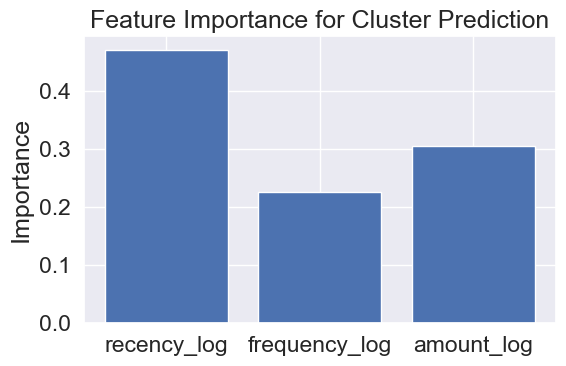

In [78]:
import pandas as pd
import numpy as np
import os
from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import matplotlib.pyplot as plt

# === 1. Load Data ===
# df = pd.read_csv('customer_history.csv')

# === 2. Feature Selection for Clustering ===
features = ['recency_log', 'frequency_log', 'amount_log']
X = customer_history_df[features]

# === 3. K-Means Clustering ===
kmeans = KMeans(n_clusters=3, random_state=42)
customer_history_df['clusters_3'] = kmeans.fit_predict(X)

# === 4. Prepare for Random Forest ===
y = customer_history_df['clusters_3']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === 5. Train Random Forest ===
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# === 6. Make Predictions ===
y_pred = rf.predict(X_test)

# === 7. Save Results to Folder ===
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
results_dir = f"rf_test_results_{timestamp}"
os.makedirs(results_dir, exist_ok=True)

# 7.1 Save accuracy
accuracy = accuracy_score(y_test, y_pred)
with open(os.path.join(results_dir, 'accuracy.txt'), 'w') as f:
    f.write(f"Accuracy: {accuracy:.4f}\n")

# 7.2 Save predictions vs actuals
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results_df.to_csv(os.path.join(results_dir, 'predictions.csv'), index=False)

# 7.3 Save confusion matrix
cm = confusion_matrix(y_test, y_pred)
np.savetxt(os.path.join(results_dir, 'confusion_matrix.csv'), cm, delimiter=',', fmt='%d')

# 7.4 Save classification report
report = classification_report(y_test, y_pred)
with open(os.path.join(results_dir, 'classification_report.txt'), 'w') as f:
    f.write(report)

# 7.5 Save feature importances
feature_importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
fi_df.to_csv(os.path.join(results_dir, 'feature_importance.csv'), index=False)

# 7.6 Save Random Forest model for later use
joblib.dump(rf, os.path.join(results_dir, 'rf_model.joblib'))

# 7.7 (Optional) Save KMeans model too
joblib.dump(kmeans, os.path.join(results_dir, 'kmeans_model.joblib'))

print(f"All testing results saved to folder: {results_dir}")

# === 8. (Optional) Plot and Save Feature Importances ===
plt.figure(figsize=(6,4))
plt.bar(features, feature_importances)
plt.title('Feature Importance for Cluster Prediction')
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'feature_importance.png'))
plt.show()
